# 🏥 Diagnóstico de Hipotiroidismo com Machine Learning
## Metodologia CRISP-DM
## Projeto de Conclusão de Curso


**Base de dados:** `Base_M43_Pratique_Hypothyroid.csv`  
**Objetivo:** Desenvolver um modelo preditivo para identificar casos de hipotiroidismo  
**Metodologia:** CRISP-DM (Cross-Industry Standard Process for Data Mining)


## Índice
1. [Entendimento do Negócio](#1-entendimento-do-negócio)
2. [Entendimento dos Dados (EDA)](#2-entendimento-dos-dados)
3. [Preparação dos Dados](#3-preparação-dos-dados)
4. [Modelagem](#4-modelagem)
5. [Avaliação](#5-avaliação)
6. [Comunicação e Storytelling](#6-comunicação-e-storytelling)


## Importações e Configurações

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import learning_curve
from sklearn.utils import resample

# configuracoes de visualizacao
%matplotlib inline
mpl.style.use('ggplot')
mpl.rcParams['axes.facecolor']  = 'white'
mpl.rcParams['axes.linewidth']  = 1
mpl.rcParams['xtick.color']     = 'black'
mpl.rcParams['ytick.color']     = 'black'
mpl.rcParams['grid.color']      = 'lightgray'
mpl.rcParams['figure.dpi']      = 150
mpl.rcParams['axes.grid']       = True
mpl.rcParams['font.size']       = 12

color_palette = ['#023047', '#e85d04', '#0077b6', '#ff8200', '#0096c7', '#ff9c33']
sns.set_palette(sns.color_palette(color_palette))
sns.color_palette(color_palette)

SEED = 42

# cria a pasta de imagens para salvar os graficos
os.makedirs('images', exist_ok=True)
print('Imports OK')


Imports OK


> Por que configuramos tudo aqui?
>
> Centralizar imports e configurações visuais na primeira célula é uma boa prática de engenharia de notebooks: garante que todo o projeto use as mesmas versões de bibliotecas e a mesma identidade visual. O preset `ggplot` com fundo branco e DPI 150 garante gráficos nítidos e legíveis mesmo ao exportar para PDF ou apresentações. A paleta `color_palette` foi escolhida para oferecer bom contraste e acessibilidade a pessoas com daltonismo (tons de azul e laranja).


## 1. Projeto de Negócio

### 1.1 Contexto Clínico

A **glândula tireoide** regula o metabolismo, o crescimento e o desenvolvimento do organismo por meio da produção dos hormônios **T3** e **T4**, controlados pelo **TSH** (Thyroid-Stimulating Hormone) secretado pela hipófise.

O **hipotiroidismo** ocorre quando a tireoide não produz hormônios em quantidade suficiente, resultando em:
- Fadiga, ganho de peso, sensibilidade ao frio
- Depressão, bradicardia, pele seca
- Risco aumentado de doenças cardiovasculares

### 1.2 Definição do Problema

| Item | Descrição |
|---|---|
| **Tipo de tarefa** | Classificação binária supervisionada |
| **Variável-alvo** | `binaryClass` → `N` (hipotiroidismo/doente) ou `P` (saudável) |
| **Métrica principal** | **Recall** (Sensibilidade) e **F1-Score** |
| **Métrica secundária** | AUC-ROC |

### 1.3 Por que Recall?

> **Em diagnósticos médicos, um Falso Negativo (FN) é mais custoso que um Falso Positivo (FP).**  
> Não detectar um caso de hipotiroidismo pode levar a complicações graves e não tratadas.  
> Já um FP resulta apenas em exames adicionais   custo aceitável.

$$\text{Recall} = \frac{TP}{TP + FN} \quad \text{(minimizar FN)}$$

$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} \quad \text{(equilíbrio)}$$


## 2. Exploração dos Dados (EDA)

### 2.1 Carregamento e Visão Geral

In [2]:
# leitura do arquivo CSV
df = pd.read_csv('Base_M43_Pratique_Hypothyroid.csv')

print('Shape:', df.shape)
print('Classes:', df['binaryClass'].value_counts().to_dict())
print()
df.head()


Shape: (3772, 30)
Classes: {'P': 3481, 'N': 291}



,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P


In [3]:
# tipos e valores iniciais
print('Tipos de dados')
df.dtypes


Tipos de dados


age                          object
sex                          object
on thyroxine                 object
query on thyroxine           object
on antithyroid medication    object
sick                         object
pregnant                     object
thyroid surgery              object
I131 treatment               object
query hypothyroid            object
query hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object
hypopituitary                object
psych                        object
TSH measured                 object
TSH                          object
T3 measured                  object
T3                           object
TT4 measured                 object
TT4                          object
T4U measured                 object
T4U                          object
FTI measured                 object
FTI                          object
TBG measured                 object
TBG                         

In [4]:
# estatisticas descritivas gerais
df.describe(include='all').T


,count,unique,top,freq
age,3772,94,59,95
sex,3772,3,F,2480
on thyroxine,3772,2,f,3308
query on thyroxine,3772,2,f,3722
on antithyroid medication,3772,2,f,3729
sick,3772,2,f,3625
pregnant,3772,2,f,3719
thyroid surgery,3772,2,f,3719
I131 treatment,3772,2,f,3713
query hypothyroid,3772,2,f,3538


> O que estamos fazendo aqui?
>
> O carregamento e a inspeção inicial dos dados são o primeiro contato com a "matéria-prima" do projeto. Verificamos o **shape** (linhas × colunas) para entender a escala do problema, os **tipos de dado** para identificar colunas que chegaram como `object` mas deveriam ser numéricas, e o `describe()` para ter uma visão estatística rápida   médias, desvios-padrão e extremos   que já antecipa possíveis outliers e valores inconsistentes.

### 2.2 Distribuição da Variável-Alvo (Desbalanceamento de Classes)

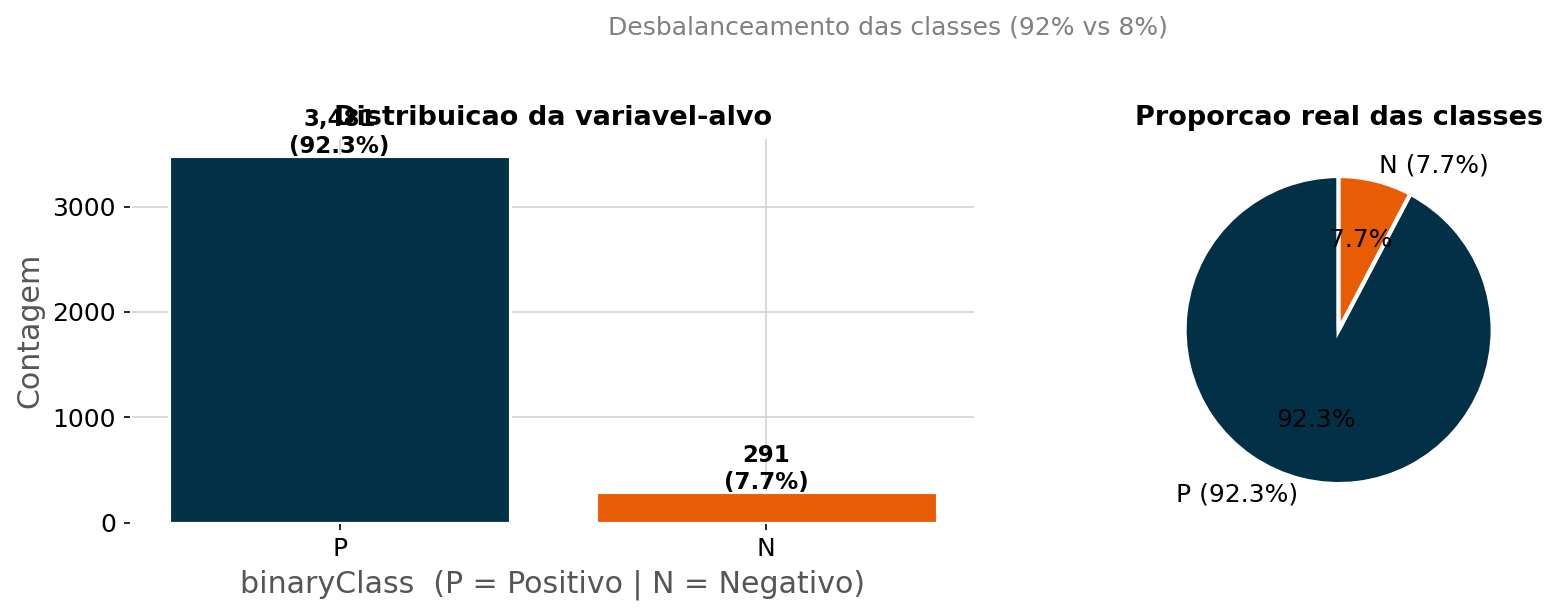

Classe majoritaria (P): 3,481 (92.3%)
Classe minoritaria (N): 291 (7.7%)
Razao de desbalanceamento: 12:1


In [5]:
# visualizacao do desbalanceamento das classes
counts = df['binaryClass'].value_counts()
pct    = df['binaryClass'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# grafico de barras da distribuicao bruta
axes[0].bar(counts.index, counts.values,
            color=[color_palette[0], color_palette[1]],
            edgecolor='white', linewidth=1.5)
for i, (val, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, val + 30, f'{val:,}\n({p:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribuicao da variavel-alvo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('binaryClass  (P = Positivo | N = Negativo)')
axes[0].set_ylabel('Contagem')

# grafico de pizza da proporcao real
axes[1].pie(counts.values,
            labels=[f'{l} ({p:.1f}%)' for l, p in zip(counts.index, pct.values)],
            colors=[color_palette[0], color_palette[1]],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporcao real das classes', fontsize=13, fontweight='bold')

plt.suptitle('Desbalanceamento das classes (92% vs 8%)',
             fontsize=12, color='gray', y=1.02)
plt.tight_layout()
plt.savefig('images/01_desbalanceamento.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Classe majoritaria (P): {counts["P"]:,} ({pct["P"]:.1f}%)')
print(f'Classe minoritaria (N): {counts["N"]:,} ({pct["N"]:.1f}%)')
print(f'Razao de desbalanceamento: {counts["P"]/counts["N"]:.0f}:1')


> Por que analisar o desbalanceamento de classes?
>
> A distribuição da variável-alvo é uma das primeiras coisas a verificar em qualquer problema de classificação. Um dataset **severamente desbalanceado** (92% Positivo vs. 8% Negativo) faz com que modelos "preguiçosos" obtenham alta acurácia simplesmente prevendo sempre a classe majoritária   sem aprender nada de útil. Identificar esse problema aqui nos guia nas decisões seguintes: uso de `class_weight='balanced'`, métricas de avaliação adequadas (Recall e F1, não Acurácia) e possível aplicação de técnicas de reamostragem como SMOTE nas próximas versões.

### 2.3 Identificação de Valores Faltantes (`?`)

Colunas com valores faltantes:


,Faltantes,Percentual (%)
TBG,3772,100.00
T3,769,20.39
T4U,387,10.26
FTI,385,10.21
TSH,369,9.78
TT4,231,6.12
sex,150,3.98
age,1,0.03


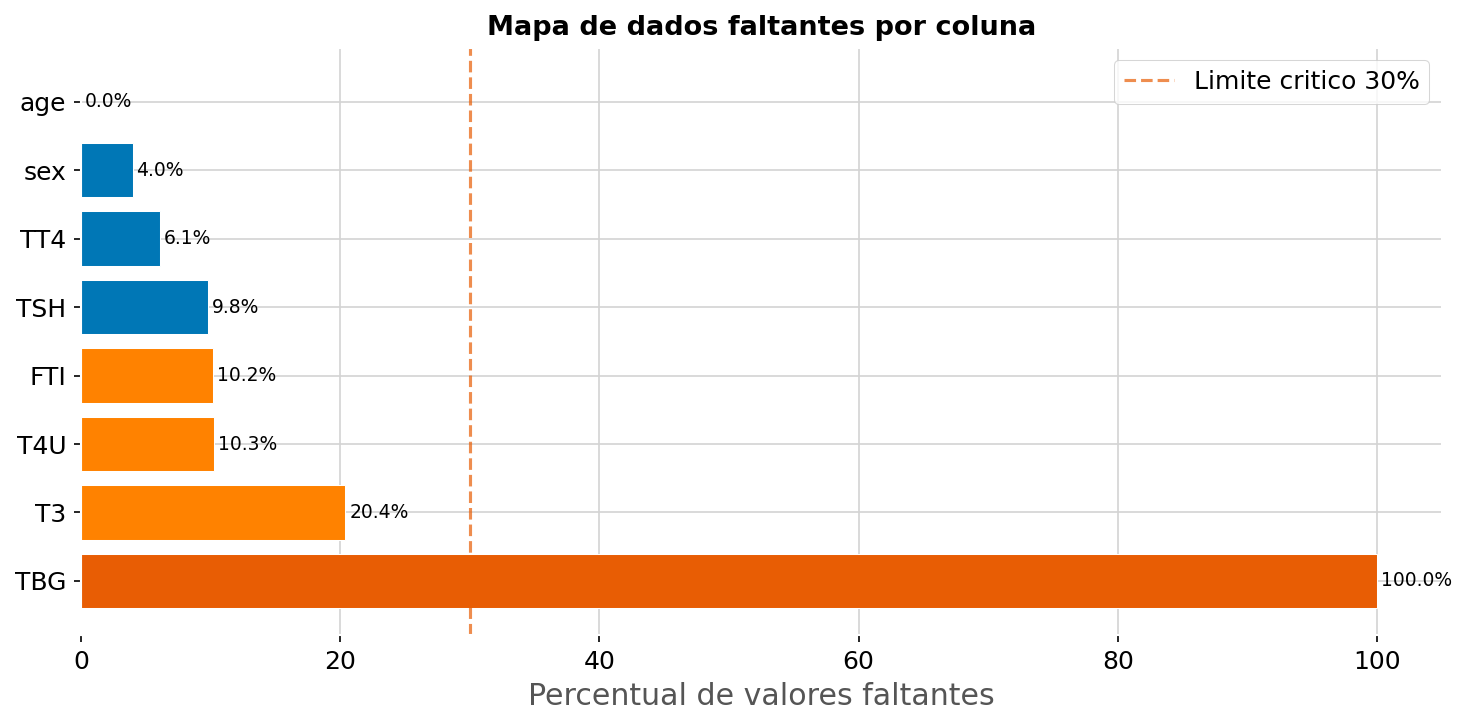

In [6]:
# mapeamento de valores faltantes: substituicao de '?' por NaN
df_raw     = df.replace('?', np.nan)
missing    = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df  = pd.DataFrame({'Faltantes': missing, 'Percentual (%)': missing_pct})
missing_df  = missing_df[missing_df['Faltantes'] > 0].sort_values('Percentual (%)', ascending=False)

print('Colunas com valores faltantes:')
display(missing_df)

# cores por nivel de criticidade: vermelho > 30%, laranja > 10%, azul restante
colors_miss = [color_palette[1] if p > 30 else color_palette[3] if p > 10 else color_palette[2]
               for p in missing_df['Percentual (%)']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Percentual (%)'],
               color=colors_miss, edgecolor='white')
for bar, pct_val in zip(bars, missing_df['Percentual (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{pct_val:.1f}%', va='center', fontsize=9)
ax.axvline(30, color=color_palette[1], linestyle='--', alpha=0.7, label='Limite critico 30%')
ax.set_xlabel('Percentual de valores faltantes')
ax.set_title('Mapa de dados faltantes por coluna', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


>  Por que mapear os valores faltantes antes de qualquer coisa?
>
> O dataset original usa `'?'` como marcador de ausência   o que não é reconhecido automaticamente pelo pandas. Convertê-los para `NaN` é essencial para que as funções de análise e imputação funcionem corretamente. Visualizar o percentual de missings por coluna permite tomar decisões informadas: colunas com mais de 70% de ausência (como `TBG`) são candidatas à remoção, enquanto colunas com ausência moderada podem ser imputadas. Ignorar este passo levaria a erros silenciosos nas etapas de modelagem.

### 2.4 Análise das Medidas Hormonais (TSH, T3, TT4, T4U, FTI)

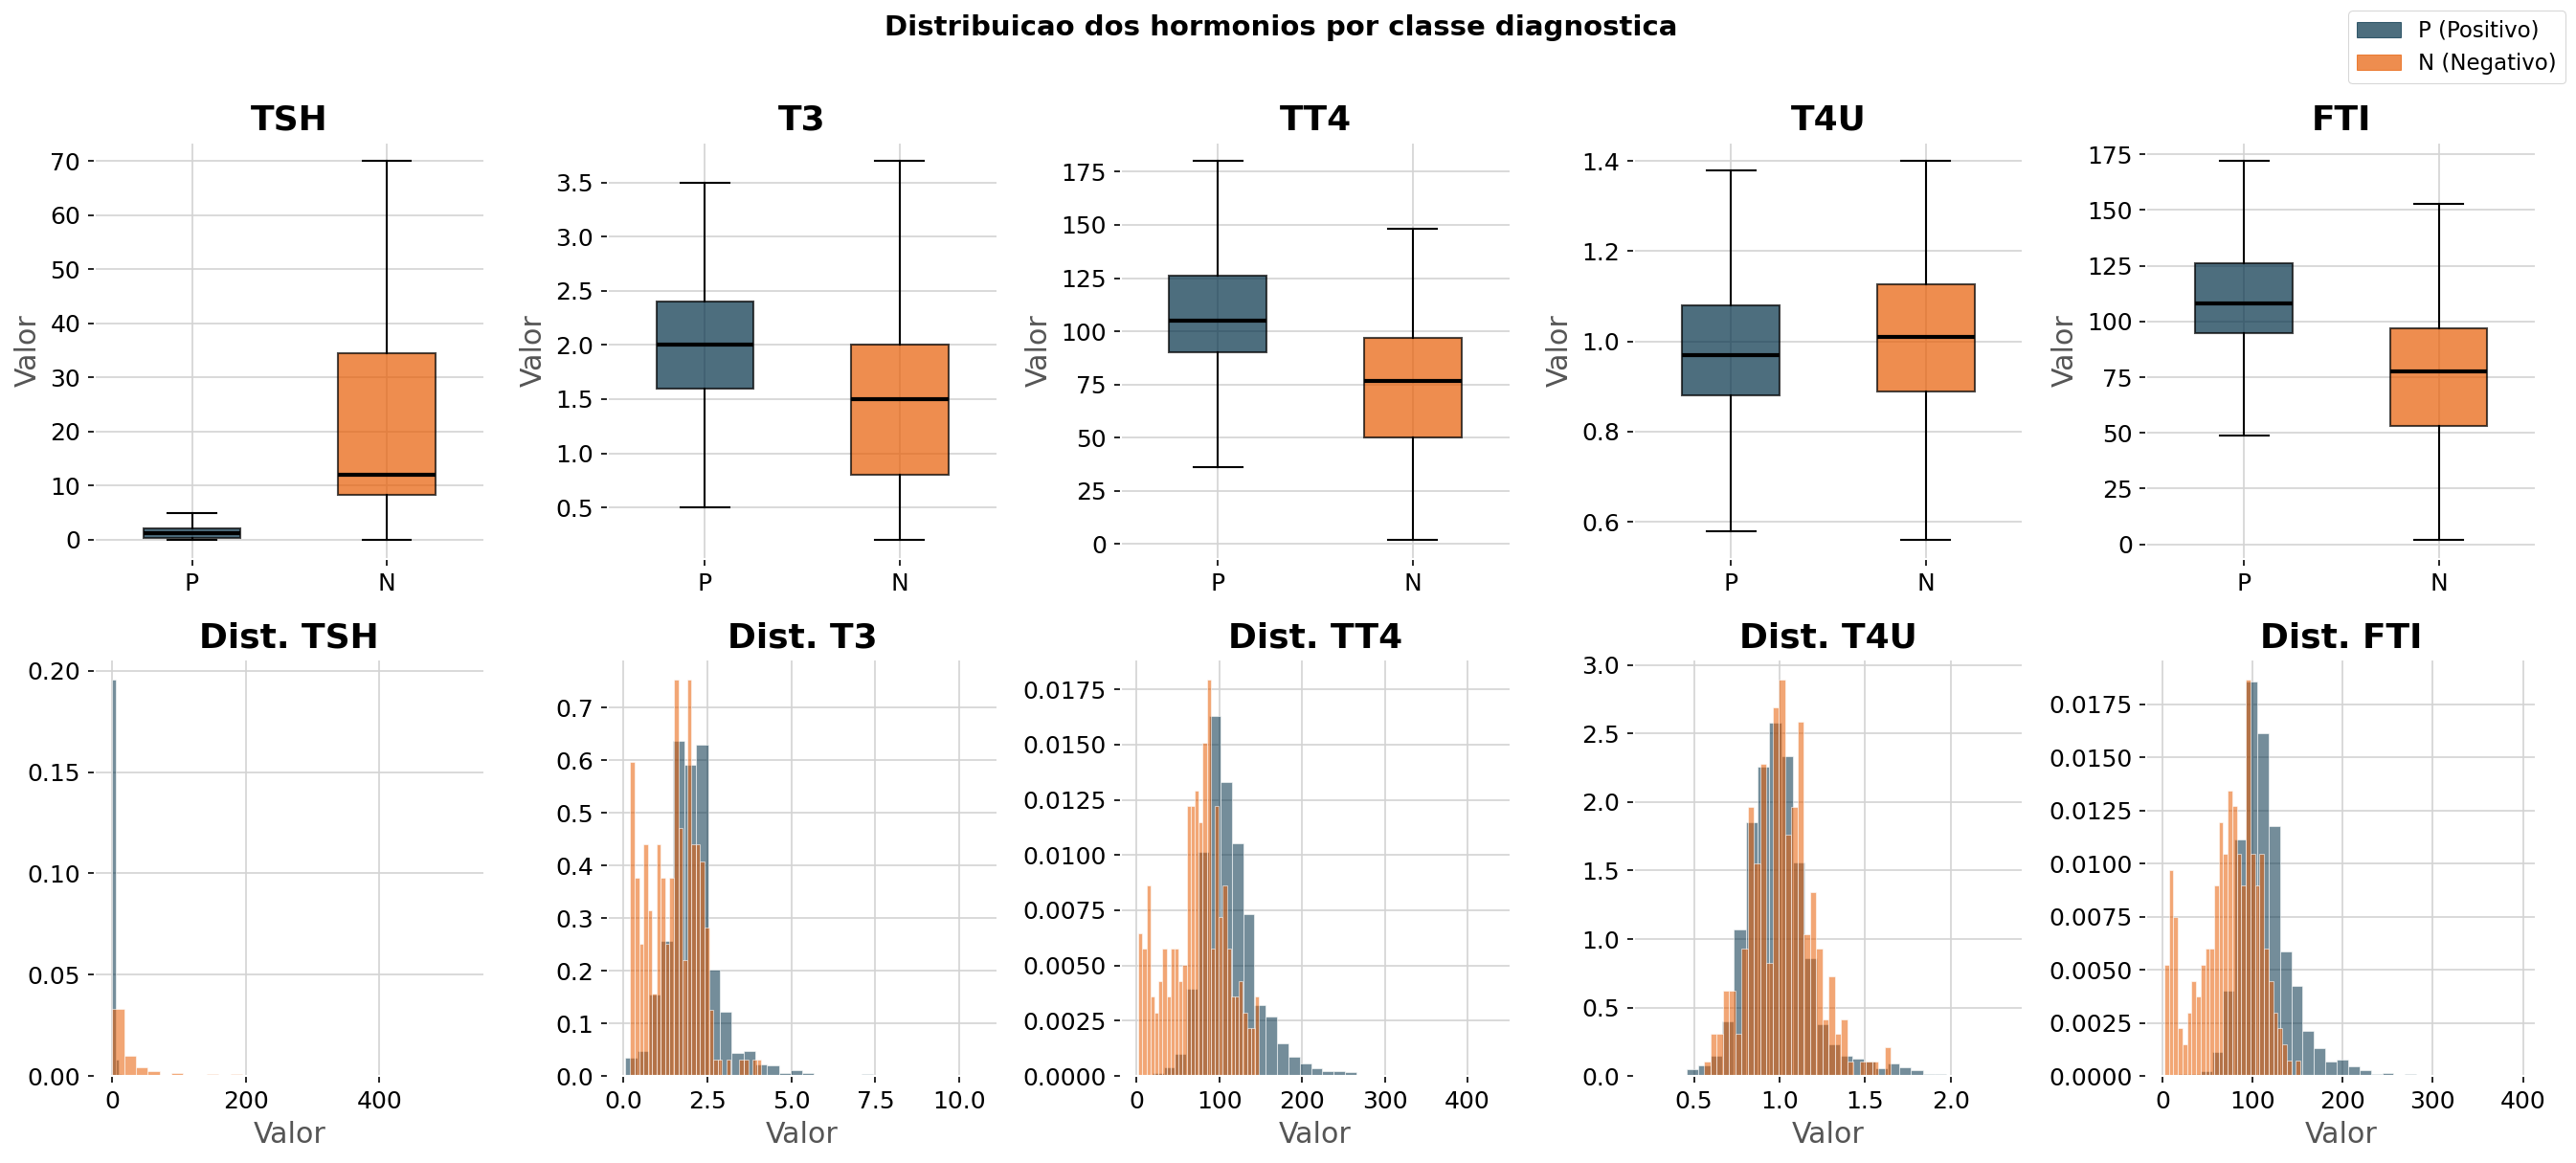

In [7]:
# distribuicao dos hormonios por classe diagnostica
hormones = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

for col in hormones:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

palette = {'P': color_palette[0], 'N': color_palette[1]}

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(hormones):
    # boxplot por classe
    for j, (cls, color) in enumerate(palette.items()):
        data_cls = df_raw[df_raw['binaryClass'] == cls][col].dropna()
        axes[0, i].boxplot(data_cls, positions=[j], widths=0.5,
                           patch_artist=True,
                           boxprops=dict(facecolor=color, alpha=0.7),
                           medianprops=dict(color='black', linewidth=2),
                           showfliers=False)
    axes[0, i].set_xticks([0, 1])
    axes[0, i].set_xticklabels(['P', 'N'])
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_ylabel('Valor')

    # histograma de densidade por classe
    for cls, color in palette.items():
        data_cls = df_raw[df_raw['binaryClass'] == cls][col].dropna()
        axes[1, i].hist(data_cls, bins=30, alpha=0.55, color=color,
                        label=cls, density=True, edgecolor='white')
    axes[1, i].set_title(f'Dist. {col}', fontweight='bold')
    axes[1, i].set_xlabel('Valor')

patch_p = mpatches.Patch(color=color_palette[0], alpha=0.7, label='P (Positivo)')
patch_n = mpatches.Patch(color=color_palette[1], alpha=0.7, label='N (Negativo)')
fig.legend(handles=[patch_p, patch_n], loc='upper right', fontsize=11)
fig.suptitle('Distribuicao dos hormonios por classe diagnostica',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/02_hormonios_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()


> Por que analisar os hormônios separados por classe diagnóstica?
>
> As medidas hormonais (TSH, T3, TT4, T4U, FTI) são o coração clínico do diagnóstico de hipotiroidismo. Ao plotar boxplots e histogramas **separados por classe** (Positivo vs. Negativo), estamos verificando se essas variáveis possuem **poder discriminativo** ou seja, se os valores diferem significativamente entre pacientes doentes e saudáveis. Se não houvesse separação visual entre as distribuições, esses atributos teriam baixo valor preditivo. Esta análise antecipa o que o SHAP confirmará na fase de avaliação: **TSH é o principal sinal clínico**.

### 2.4.1 Diagnostico de Normalidade dos Hormonios

Os histogramas acima mostram a forma das distribuicoes, mas nao respondem formalmente se os hormonios seguem distribuicao normal. Essa pergunta importa por duas razoes praticas:

1. **Define qual teste estatistico usar** na analise de significancia: se os dados fossem normais, o teste t seria o mais indicado; como sao assimetricos, o teste de Mann-Whitney (nao parametrico) e o correto.
2. **Justifica a escolha do algoritmo**: modelos lineares assumem normalidade, arvores de decisao nao. Comprovar a assimetria reforca por que LightGBM e XGBoost sao escolhas mais adequadas aqui.

O Q-Q plot e a ferramenta visual padrao: se os pontos seguem a diagonal, a distribuicao e normal; desvios nas pontas indicam caudas pesadas. Complementamos com o teste de D'Agostino-Pearson, robusto para amostras deste tamanho.

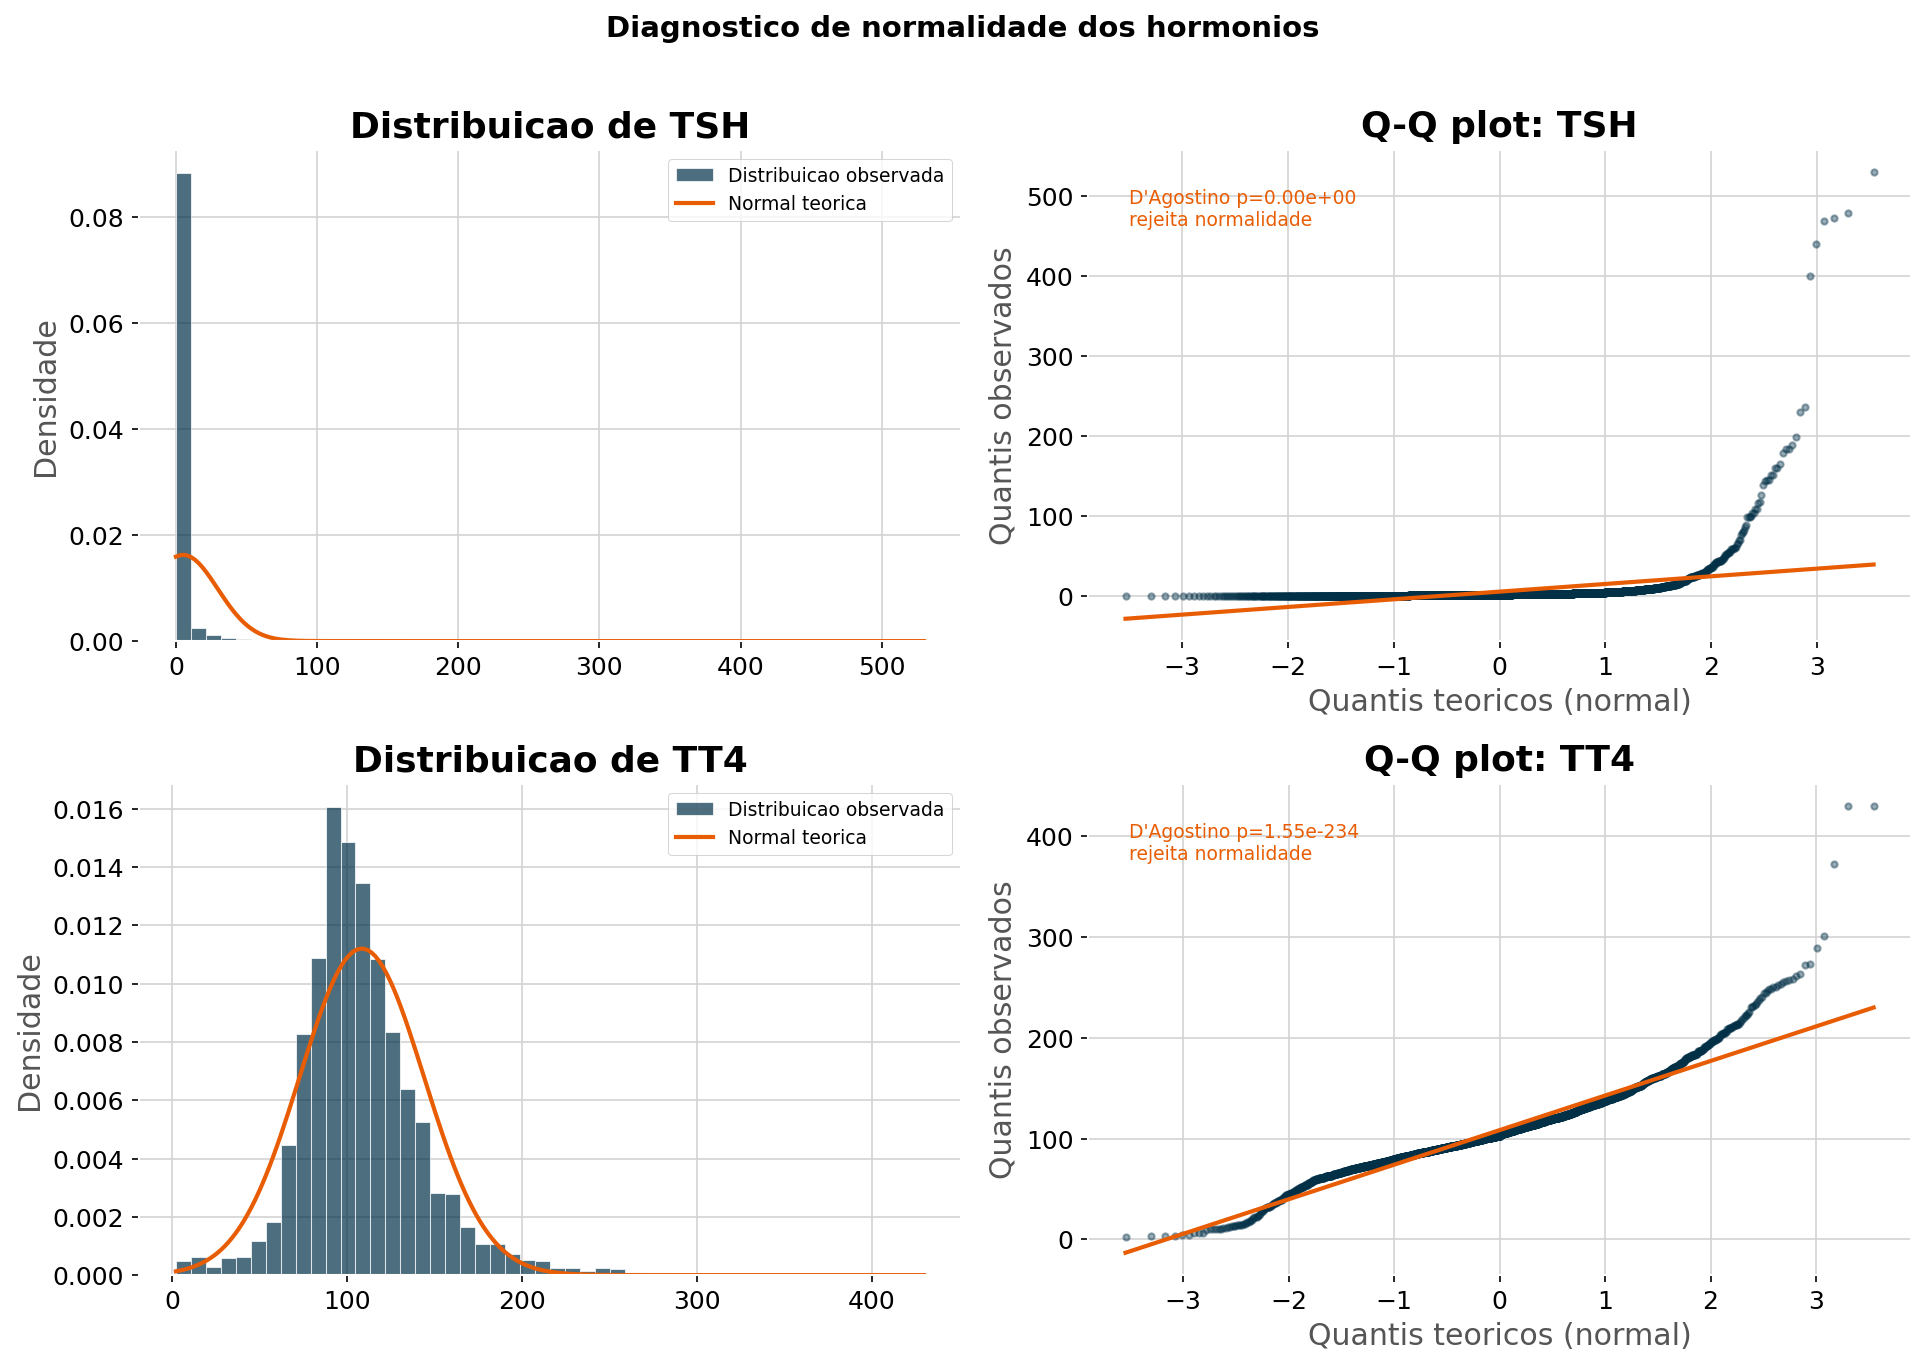

Os hormonios sao fortemente assimetricos e nao normais.
Isso justifica o uso do teste de Mann-Whitney na analise de significancia
e reforca a escolha de modelos baseados em arvores, que nao assumem normalidade.


In [8]:
# diagnostico de normalidade dos principais hormonios via Q-Q plot e teste de D'Agostino
hormones_norm = ['TSH', 'TT4']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, col in enumerate(hormones_norm):
    amostra = pd.to_numeric(df_raw[col], errors='coerce').dropna()

    # histograma com curva normal teorica sobreposta
    ax_hist = axes[row, 0]
    ax_hist.hist(amostra, bins=50, density=True, color=color_palette[0],
                 alpha=0.7, edgecolor='white', label='Distribuicao observada')
    mu, sigma = amostra.mean(), amostra.std()
    x_norm = np.linspace(amostra.min(), amostra.max(), 200)
    ax_hist.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma),
                 color=color_palette[1], linewidth=2, label='Normal teorica')
    ax_hist.set_title(f'Distribuicao de {col}', fontweight='bold')
    ax_hist.set_ylabel('Densidade')
    ax_hist.legend(fontsize=9)

    # Q-Q plot
    ax_qq = axes[row, 1]
    (osm, osr), (slope, intercept, r) = stats.probplot(amostra, dist='norm')
    ax_qq.plot(osm, osr, 'o', color=color_palette[0], alpha=0.4, markersize=3)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color=color_palette[1], linewidth=2)
    ax_qq.set_title(f'Q-Q plot: {col}', fontweight='bold')
    ax_qq.set_xlabel('Quantis teoricos (normal)')
    ax_qq.set_ylabel('Quantis observados')

    # teste de D'Agostino-Pearson
    stat, p = stats.normaltest(amostra)
    conclusao = 'rejeita normalidade' if p < 0.05 else 'nao rejeita normalidade'
    ax_qq.text(0.05, 0.92, f"D'Agostino p={p:.2e}\n{conclusao}",
               transform=ax_qq.transAxes, fontsize=9,
               color=color_palette[1] if p < 0.05 else color_palette[0],
               verticalalignment='top')

plt.suptitle('Diagnostico de normalidade dos hormonios',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/03_normalidade.png', dpi=150, bbox_inches='tight')
plt.show()

print('Os hormonios sao fortemente assimetricos e nao normais.')
print('Isso justifica o uso do teste de Mann-Whitney na analise de significancia')
print('e reforca a escolha de modelos baseados em arvores, que nao assumem normalidade.')

> O que esse diagnostico revela?
>
> Os Q-Q plots confirmam visualmente o que os histogramas sugeriam: os hormonios fogem muito da diagonal normal, especialmente nas caudas. O TSH em particular tem cauda longa a direita, onde vivem justamente os casos de hipotiroidismo severo. O teste de D'Agostino formaliza isso com p-valor. A conclusao pratica e dupla: usaremos testes nao parametricos na proxima analise estatistica, e temos fundamento solido para preferir arvores de decisao a modelos lineares.

### 2.5 Correlação entre Medidas Hormonais

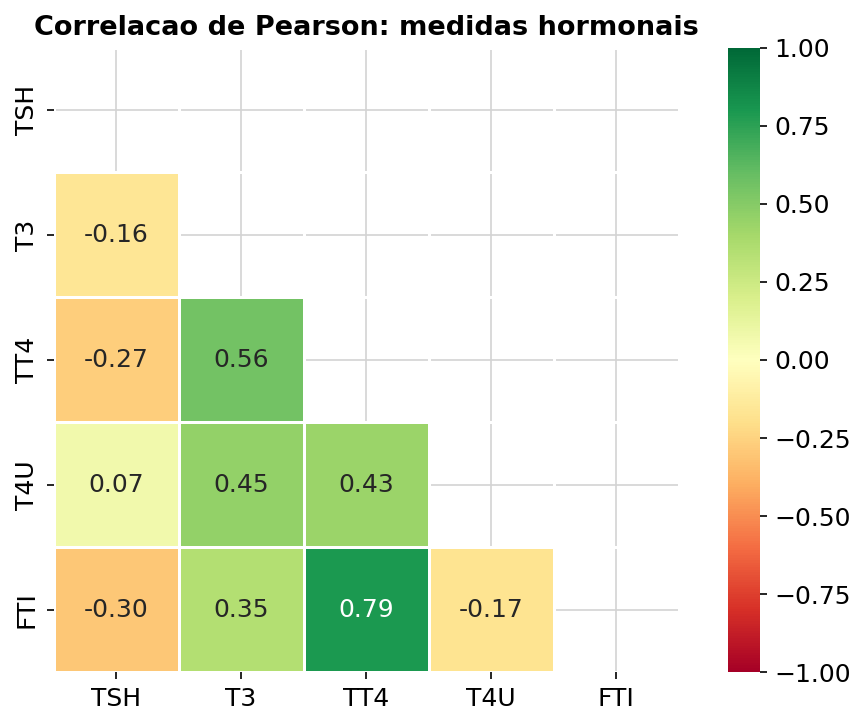

TT4 e FTI apresentam alta correlacao positiva (FTI e calculado a partir do TT4).
TSH elevado tende a indicar hipotiroidismo.


In [9]:
# correlacao de pearson entre as medidas hormonais
corr_matrix = df_raw[hormones].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white', square=True)
ax.set_title('Correlacao de Pearson: medidas hormonais', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('TT4 e FTI apresentam alta correlacao positiva (FTI e calculado a partir do TT4).')
print('TSH elevado tende a indicar hipotiroidismo.')


>  Para que serve a matriz de correlação aqui?
>
> Variáveis altamente correlacionadas carregam informação redundante. Identificar que `TT4` e `FTI` têm alta correlação (o FTI é calculado a partir do TT4) nos avisa que incluir ambas pode introduzir **multicolinearidade**   especialmente problemática para a Regressão Logística. Modelos baseados em árvores (Random Forest, LightGBM, XGBoost) são naturalmente mais robustos a isso, mas a informação ainda é útil para interpretabilidade e possível engenharia de features futura.

### 2.5.1 Diagnostico de Multicolinearidade (VIF)

A matriz de correlacao acima ja sinaliza que TT4 e FTI sao altamente correlacionados, o que faz sentido clinico: o FTI (Indice de Tiroxina Livre) e calculado a partir do TT4 e do T4U. Mas a correlacao mede apenas relacoes entre pares. O VIF (Variance Inflation Factor) vai alem: mede quanto a variancia do coeficiente de uma variavel e inflada pela presenca de todas as outras simultaneamente.

Para cada variavel, o VIF e calculado como `1 / (1 - R2)`, onde `R2` vem de uma regressao dessa variavel sobre todas as demais.

| VIF | Interpretacao |
|-----|---------------|
| 1 | Sem colinearidade |
| 1 a 5 | Colinearidade baixa, aceitavel |
| 5 a 10 | Colinearidade moderada, investigar |
| acima de 10 | Colinearidade severa |

Como o FTI deriva matematicamente do TT4, a expectativa e que ambos apresentem VIF elevado, confirmando de forma quantitativa a redundancia que a correlacao sugeria.

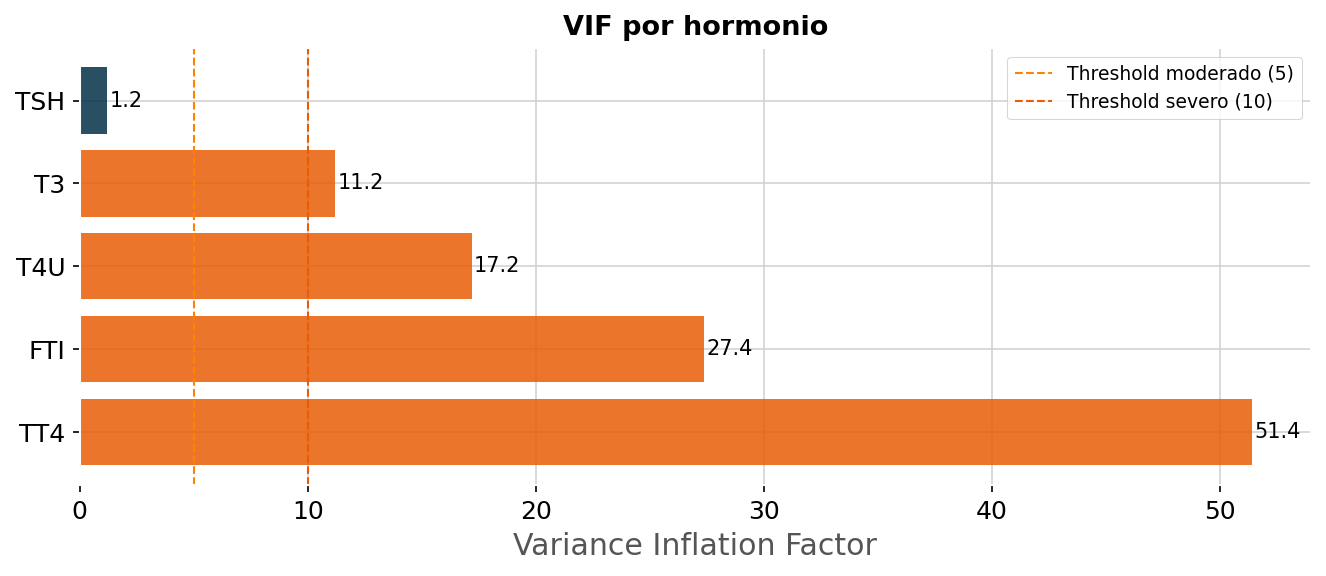

Resumo VIF:
variavel       VIF
     TT4 51.433545
     FTI 27.392134
     T4U 17.192500
      T3 11.212817
     TSH  1.196928

Hormonios com multicolinearidade severa (VIF >= 10): ['TT4', 'FTI', 'T4U', 'T3']
A relacao de calculo entre FTI, TT4 e T4U explica esse resultado.


In [10]:
# VIF dos hormonios para quantificar a multicolinearidade
df_vif = df_raw[hormones].apply(pd.to_numeric, errors='coerce').dropna()

vif_resultado = pd.DataFrame({
    'variavel': hormones,
    'VIF': [variance_inflation_factor(df_vif.values, i)
            for i in range(df_vif.shape[1])]
})
vif_resultado = vif_resultado.sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
cores_vif = [color_palette[1] if v >= 10 else color_palette[3] if v >= 5 else color_palette[0]
             for v in vif_resultado['VIF']]
bars = ax.barh(vif_resultado['variavel'], vif_resultado['VIF'], color=cores_vif, alpha=0.85)
ax.axvline(5,  color=color_palette[3], linestyle='--', linewidth=1, label='Threshold moderado (5)')
ax.axvline(10, color=color_palette[1], linestyle='--', linewidth=1, label='Threshold severo (10)')
ax.set_title('VIF por hormonio', fontsize=13, fontweight='bold')
ax.set_xlabel('Variance Inflation Factor')
ax.legend(fontsize=9)
for bar, val in zip(bars, vif_resultado['VIF']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('images/04_vif.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumo VIF:')
print(vif_resultado.to_string(index=False))
severas = vif_resultado[vif_resultado['VIF'] >= 10]
if not severas.empty:
    print(f'\nHormonios com multicolinearidade severa (VIF >= 10): {severas["variavel"].tolist()}')
    print('A relacao de calculo entre FTI, TT4 e T4U explica esse resultado.')

> Por que o VIF importa aqui?
>
> Confirmada a multicolinearidade, surge a pergunta: precisamos remover variaveis? Para modelos lineares (como a Regressao Logistica baseline), sim, a multicolinearidade desestabiliza os coeficientes. Para os modelos de arvore (LightGBM, XGBoost, Random Forest), que sao os candidatos reais a campeao, a multicolinearidade nao prejudica a performance, pois eles escolhem uma variavel por vez nos splits. A decisao do projeto e manter as variaveis para preservar a interpretabilidade clinica, mas agora com a consciencia quantitativa de que FTI, TT4 e T4U carregam informacao sobreposta.

### 2.6 Perfil do Paciente: Idade, Sexo e Gravidez

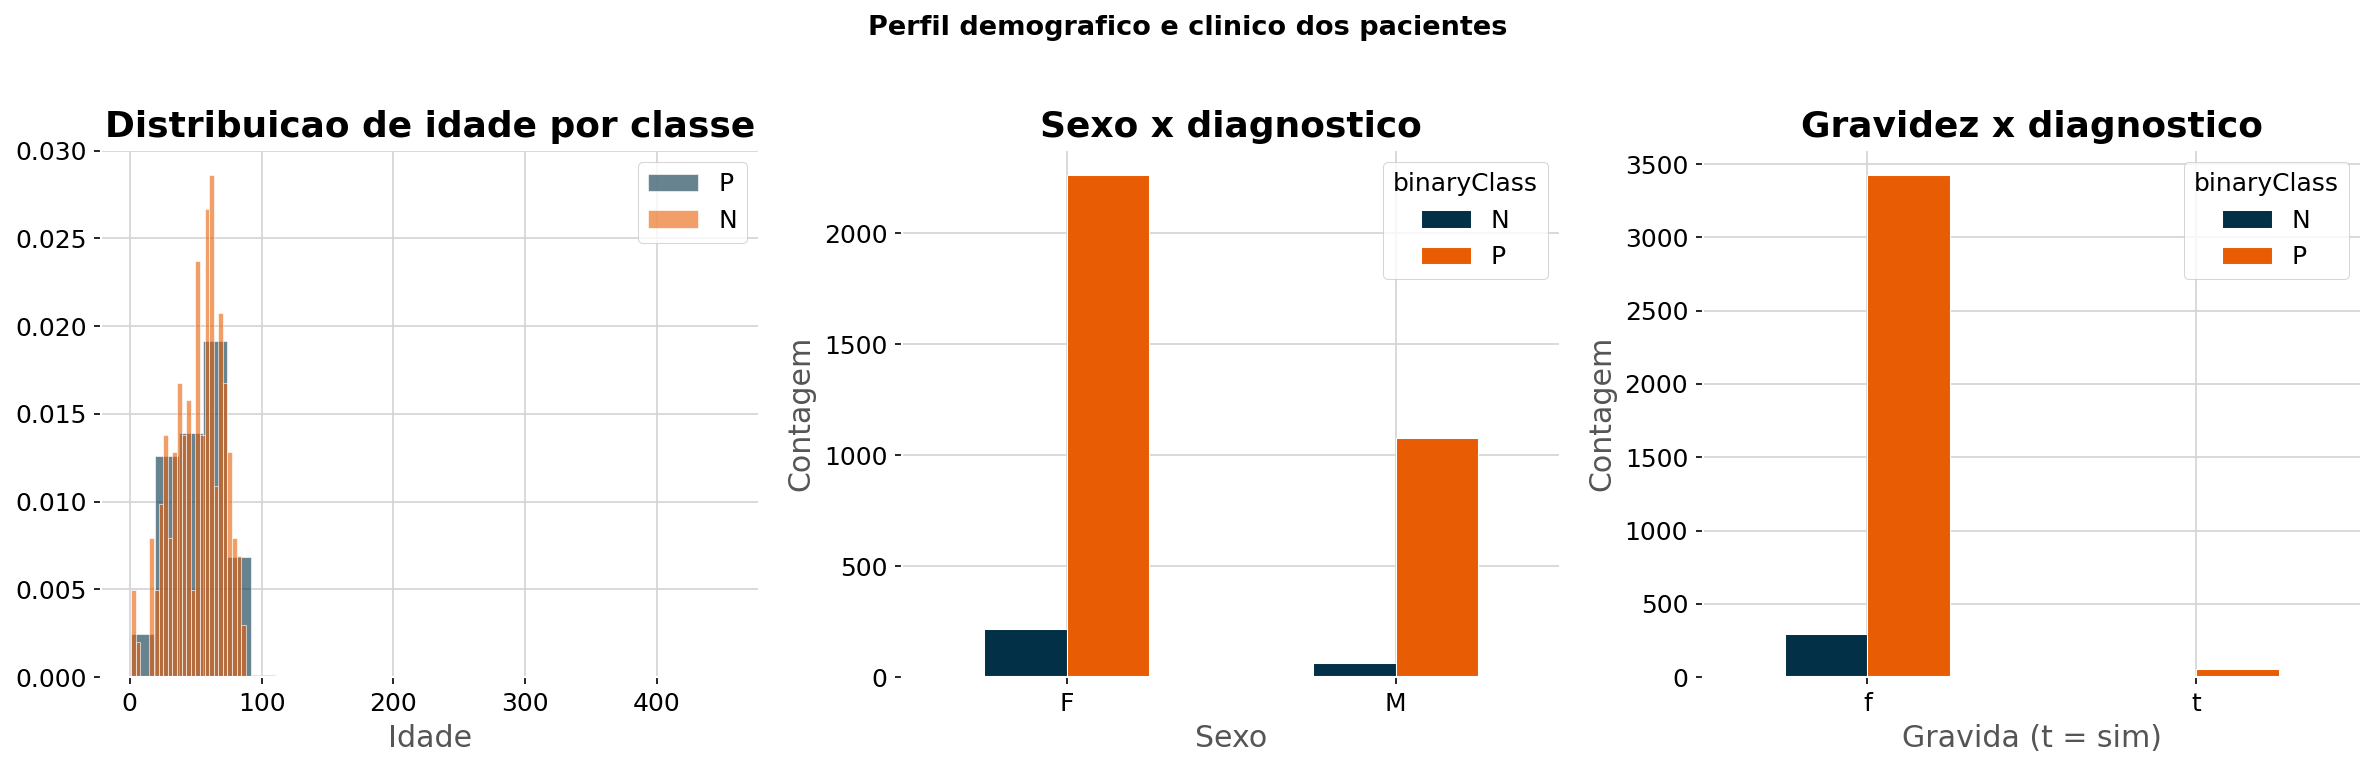

In [11]:
# perfil demografico e clinico dos pacientes
df_raw['age'] = pd.to_numeric(df_raw['age'], errors='coerce')

palette = {'P': color_palette[0], 'N': color_palette[1]}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# distribuicao de idade por classe
for cls, color in palette.items():
    d = df_raw[df_raw['binaryClass'] == cls]['age'].dropna()
    axes[0].hist(d, bins=25, alpha=0.6, color=color, label=cls,
                 density=True, edgecolor='white')
axes[0].set_title('Distribuicao de idade por classe', fontweight='bold')
axes[0].set_xlabel('Idade')
axes[0].legend()

# sexo vs diagnostico
sex_counts = df_raw.groupby(['sex', 'binaryClass']).size().unstack(fill_value=0)
sex_counts.plot(kind='bar', ax=axes[1],
                color=[color_palette[0], color_palette[1]], edgecolor='white', rot=0)
axes[1].set_title('Sexo x diagnostico', fontweight='bold')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Contagem')

# gravidez vs diagnostico
preg_counts = df_raw.groupby(['pregnant', 'binaryClass']).size().unstack(fill_value=0)
preg_counts.plot(kind='bar', ax=axes[2],
                 color=[color_palette[0], color_palette[1]], edgecolor='white', rot=0)
axes[2].set_title('Gravidez x diagnostico', fontweight='bold')
axes[2].set_xlabel('Gravida (t = sim)')
axes[2].set_ylabel('Contagem')

plt.suptitle('Perfil demografico e clinico dos pacientes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


> Por que analisar o perfil demográfico?
>
> Variáveis como **idade**, **sexo** e **gravidez** são fatores de risco conhecidos para doenças da tireoide. O hipotiroidismo é mais prevalente em mulheres e sua incidência aumenta com a idade. A gravidez também é um período de maior risco hormonal. Incluir essa análise no EDA: (1) valida se o dataset reflete o conhecimento clínico, (2) confirma que essas variáveis têm potencial preditivo e merecem estar no modelo, e (3) identifica possíveis vieses de seleção amostral que poderiam afetar a generalização do modelo.

---
## 3. Preparação dos Dados

### 2.7 Significância Estatística das Variáveis

A analise SHAP, mais adiante, vai mostrar quais variaveis o modelo mais usou para decidir. Mas existe uma pergunta anterior e independente do modelo: cada variavel tem uma relacao estatistica real com o diagnostico, ou o que observamos pode ser fruto do acaso?

Como temos dois tipos de variavel, usamos dois testes complementares:

**Para os hormonios (continuos), o teste de Mann-Whitney U.** Ele compara se a distribuicao do hormonio e diferente entre pacientes doentes e saudaveis. Escolhemos Mann-Whitney em vez do teste t porque os hormonios sao assimetricos (comprovado na secao 2.4.1), e este teste nao assume normalidade.

**Para as variaveis categoricas, o teste qui-quadrado.** Ele verifica se a frequencia de uma categoria esta associada ao diagnostico, por exemplo, se pacientes em uso de tiroxina tem taxa de hipotiroidismo diferente.

Em ambos, a hipotese nula e que nao ha relacao com o diagnostico. Um p-valor abaixo de 0.05 nos permite rejeitar essa hipotese e concluir que a variavel e estatisticamente significativa.

TESTE DE MANN-WHITNEY U (hormonios continuos)
  TSH    | p=3.19e-166 | SIGNIFICATIVO
  T3     | p=1.59e-25 | SIGNIFICATIVO
  TT4    | p=3.76e-59 | SIGNIFICATIVO
  T4U    | p=4.96e-03 | SIGNIFICATIVO
  FTI    | p=5.02e-67 | SIGNIFICATIVO

TESTE QUI-QUADRADO (variaveis categoricas)
  on thyroxine       | p=1.03e-06 | SIGNIFICATIVO
  sick               | p=1.00e+00 | nao significativo
  pregnant           | p=6.28e-02 | nao significativo
  thyroid surgery    | p=4.10e-01 | nao significativo
  query hypothyroid  | p=2.31e-07 | SIGNIFICATIVO
  tumor              | p=9.71e-01 | nao significativo
  goitre             | p=1.70e-01 | nao significativo
  sex                | p=2.28e-03 | SIGNIFICATIVO


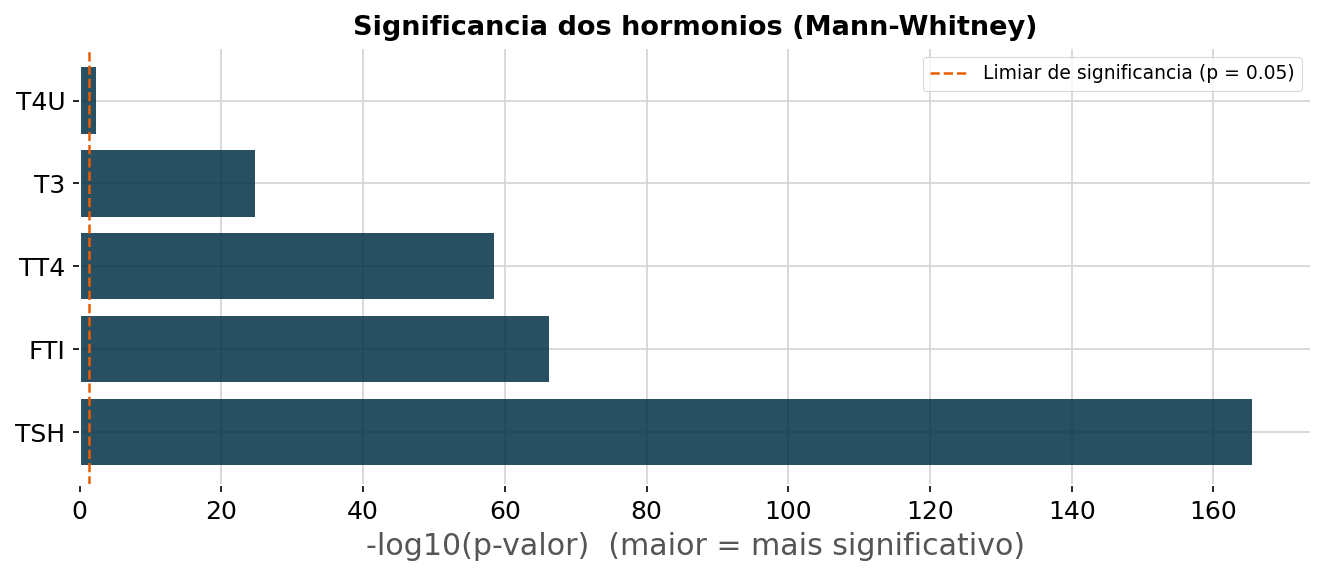

In [12]:
# teste de significancia: Mann-Whitney para hormonios, qui-quadrado para categoricas
# usa df_clean ja com o target mapeado (1 = doente, 0 = saudavel) seria ideal,
# mas aqui usamos df_raw para preservar os valores originais antes do encoding
df_sig = df.copy().replace('?', np.nan)
for col in hormones:
    df_sig[col] = pd.to_numeric(df_sig[col], errors='coerce')
df_sig['alvo'] = (df_sig['binaryClass'] == 'N').astype(int)  # N = doente

# 1. Mann-Whitney para os hormonios
print('=' * 60)
print('TESTE DE MANN-WHITNEY U (hormonios continuos)')
print('=' * 60)
resultados_mw = []
for col in hormones:
    doentes   = df_sig[df_sig['alvo'] == 1][col].dropna()
    saudaveis = df_sig[df_sig['alvo'] == 0][col].dropna()
    stat, p = mannwhitneyu(doentes, saudaveis, alternative='two-sided')
    sig = 'SIGNIFICATIVO' if p < 0.05 else 'nao significativo'
    resultados_mw.append({'hormonio': col, 'p_valor': p, 'conclusao': sig})
    print(f'  {col:6} | p={p:.2e} | {sig}')

# 2. Qui-quadrado para as principais categoricas clinicas
print('\n' + '=' * 60)
print('TESTE QUI-QUADRADO (variaveis categoricas)')
print('=' * 60)
cat_teste = ['on thyroxine', 'sick', 'pregnant', 'thyroid surgery',
             'query hypothyroid', 'tumor', 'goitre', 'sex']
resultados_chi = []
for col in cat_teste:
    if col not in df_sig.columns:
        continue
    tabela = pd.crosstab(df_sig[col], df_sig['alvo'])
    chi2, p, dof, exp = chi2_contingency(tabela)
    sig = 'SIGNIFICATIVO' if p < 0.05 else 'nao significativo'
    resultados_chi.append({'variavel': col, 'p_valor': p, 'conclusao': sig})
    print(f'  {col:18} | p={p:.2e} | {sig}')

# visualizacao dos p-valores dos hormonios
df_mw = pd.DataFrame(resultados_mw).sort_values('p_valor')
fig, ax = plt.subplots(figsize=(9, 4))
cores_p = [color_palette[0] if p < 0.05 else color_palette[1] for p in df_mw['p_valor']]
ax.barh(df_mw['hormonio'], -np.log10(df_mw['p_valor'] + 1e-300), color=cores_p, alpha=0.85)
ax.axvline(-np.log10(0.05), color=color_palette[1], linestyle='--', linewidth=1.2,
           label='Limiar de significancia (p = 0.05)')
ax.set_title('Significancia dos hormonios (Mann-Whitney)', fontsize=13, fontweight='bold')
ax.set_xlabel('-log10(p-valor)  (maior = mais significativo)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/05_significancia.png', dpi=150, bbox_inches='tight')
plt.show()

> O que os testes de significancia agregam ao projeto?
>
> Eles trazem uma camada de evidencia que o SHAP sozinho nao oferece. O SHAP diz o que o modelo aprendeu a usar; os testes de hipotese dizem o que tem suporte estatistico independente de qualquer modelo. Quando o TSH aparece como altamente significativo no Mann-Whitney e tambem no topo do SHAP, temos duas evidencias convergentes, vindas de caminhos diferentes, apontando para a mesma verdade clinica. Isso e o tipo de robustez que distingue um projeto solido de uma simples aplicacao de algoritmo.

## 3. Preparação dos Dados

Com os dados compreendidos e diagnosticados estatisticamente, preparamos o dataset para a modelagem. Cada decisão segue os achados da fase anterior: tratamos os valores faltantes mascarados como `?`, decidimos sobre os outliers hormonais com base no significado clínico, codificamos as variáveis e separamos treino e teste com estratificação para preservar a proporção entre as classes.

### 3.1 Limpeza e Conversão de  `?`  para NaN e Tipagem

In [13]:
# copia limpa do dataframe com tipagem correta das colunas numericas
df_clean = df.copy().replace('?', np.nan)

num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print('Tipos apos conversao:')
print(df_clean[num_cols].dtypes)
print()
print(f'Shape: {df_clean.shape}')


Tipos apos conversao:
age    float64
TSH    float64
T3     float64
TT4    float64
T4U    float64
FTI    float64
TBG    float64
dtype: object

Shape: (3772, 30)


> Por que criar uma cópia limpa do DataFrame?
>
> Trabalhar sempre em uma cópia (`df.copy()`) é uma prática defensiva fundamental: preserva o dataset original intacto para que possamos rever ou reprocessar dados sem precisar recarregar o arquivo. A conversão de `'?'` para `NaN` e a tipagem explícita das colunas numéricas são passos obrigatórios   o pandas lê colunas com valores mistos (números + `'?'`) como `object`, e operações como média e correlação só funcionam corretamente com tipos numéricos reais.

### 3.2 Análise de Outliers nos Hormônios

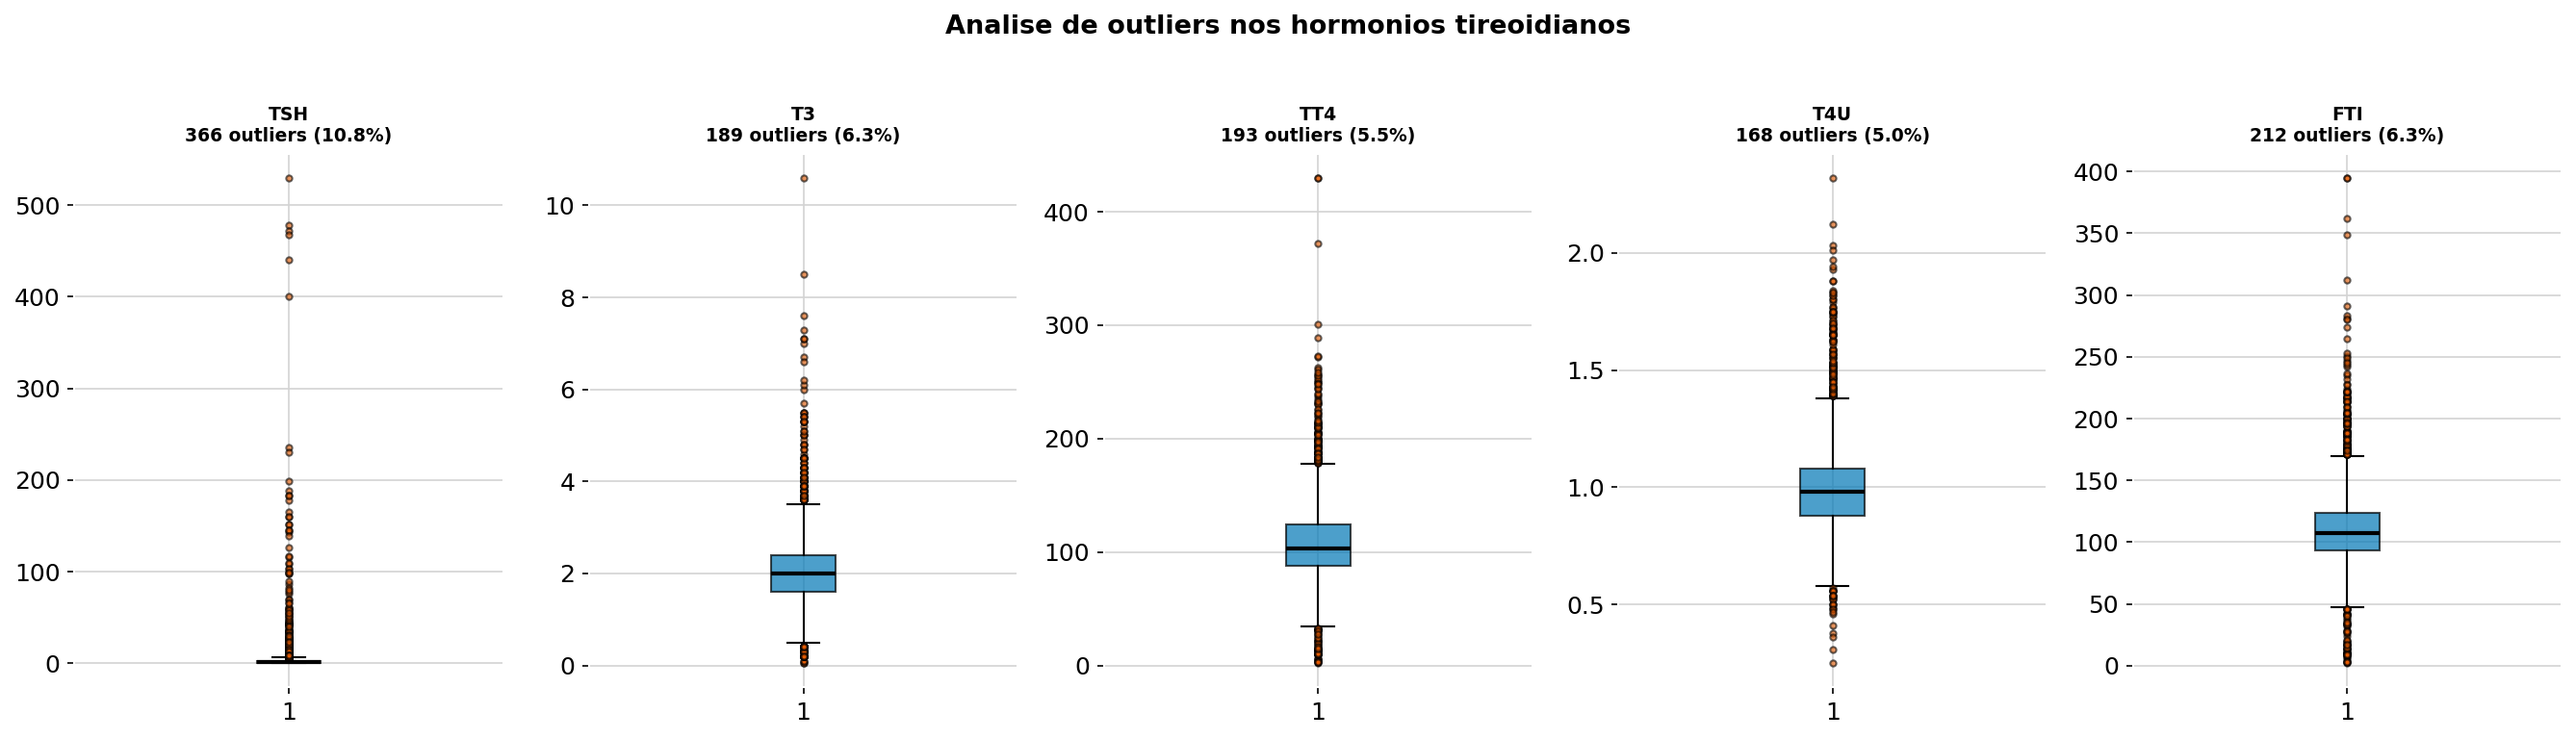

Valores extremos de TSH sao clinicamente relevantes e serao mantidos.
Idades acima de 100 anos serao tratadas como erro de digitacao.

Idades > 100: 1 registros substituidos por NaN


In [14]:
# analise de outliers nos hormonios via boxplot com contagem por IQR
hormones = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']  # redefinido para garantir escopo sobre df_clean

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(hormones):
    d        = df_clean[col].dropna()
    q1, q3   = d.quantile(0.25), d.quantile(0.75)
    iqr      = q3 - q1
    outliers = d[(d < q1 - 1.5 * iqr) | (d > q3 + 1.5 * iqr)]

    axes[i].boxplot(d, patch_artist=True,
                    boxprops=dict(facecolor=color_palette[2], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=color_palette[1],
                                    markersize=3, alpha=0.6))
    axes[i].set_title(
        f'{col}\n{len(outliers)} outliers ({len(outliers)/len(d)*100:.1f}%)',
        fontweight='bold', fontsize=9)

plt.suptitle('Analise de outliers nos hormonios tireoidianos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Valores extremos de TSH sao clinicamente relevantes e serao mantidos.')
print('Idades acima de 100 anos serao tratadas como erro de digitacao.')

# trata idades improvaveis
print(f'\nIdades > 100: {(df_clean["age"] > 100).sum()} registros substituidos por NaN')
df_clean.loc[df_clean['age'] > 100, 'age'] = np.nan


> Por que analisar outliers mas não removê-los?
>
> Em dados clínicos, outliers nem sempre são erros   frequentemente são o **sinal mais importante**. Um TSH extremamente elevado, por exemplo, é exatamente o que caracteriza o hipotiroidismo severo: removê-lo seria apagar a evidência mais valiosa para o modelo. A decisão técnica adotada foi **manter os outliers hormonais** (preservando o sinal clínico) e tratar apenas idades biologicamente impossíveis (> 100 anos), que são claramente erros de digitação. Esta é a diferença entre uma abordagem estatística cega e uma abordagem orientada pelo domínio do negócio.

### 3.3 Codificação das Variáveis

In [15]:
# encoding das variaveis categoricas e booleanas

# colunas booleanas: f/t para 0/1
bool_cols = [
    'on thyroxine', 'query on thyroxine', 'on antithyroid medication',
    'sick', 'pregnant', 'thyroid surgery', 'I131 treatment',
    'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre',
    'tumor', 'hypopituitary', 'psych',
    'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured',
    'FTI measured', 'TBG measured'
]
for col in bool_cols:
    df_clean[col] = df_clean[col].map({'t': 1, 'f': 0})

# sexo: F/M para 0/1
df_clean['sex'] = df_clean['sex'].map({'F': 0, 'M': 1})

# referral source: label encoding (variavel nominal sem ordem)
le = LabelEncoder()
df_clean['referral source'] = le.fit_transform(df_clean['referral source'].fillna('unknown'))
print('Categorias referral source:', le.classes_)

# target: N = 1 (hipotiroidismo), P = 0 (saudavel)
# convencao corrigida: a classe positiva representa a doenca, como e padrao em ML clinico
# o TSH mediano confirma: classe N tem TSH ~12 (elevado, doente), classe P tem TSH ~1.2 (normal)
df_clean['binaryClass'] = df_clean['binaryClass'].map({'N': 1, 'P': 0})

print('\nEncoding concluido')
df_clean.head(3)


Categorias referral source: ['STMW' 'SVHC' 'SVHD' 'SVI' 'other']

Encoding concluido


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41.0,0.0,0,0,0,0,0,0,0,0,...,1,125.0,1,1.14,1,109.0,0,NaN,1,0
1,23.0,0.0,0,0,0,0,0,0,0,0,...,1,102.0,0,NaN,0,NaN,0,NaN,4,0
2,46.0,1.0,0,0,0,0,0,0,0,0,...,1,109.0,1,0.91,1,120.0,0,NaN,4,0


> Por que codificar variáveis categóricas e booleanas?
>
> Algoritmos de machine learning trabalham exclusivamente com números. As variáveis booleanas (`'t'`/`'f'`) são convertidas para `1`/`0`, mantendo a semântica binária. O sexo (`'F'`/`'M'`) também recebe codificação binária. Para `referral source` (variável com múltiplas categorias nominais sem ordem), usamos `LabelEncoder`   uma abordagem simples que funciona bem para modelos baseados em árvores, que não assumem ordenação. Em modelos lineares, preferiríamos `OneHotEncoding` para evitar a interpretação de ordem implícita.

### 3.4 Imputação de Valores Faltantes

In [16]:
# separacao de features e target; remocao de colunas problematicas
X = df_clean.drop(columns='binaryClass')
y = df_clean['binaryClass']

# Ponto de melhoria: remocao das colunas 'measured'
# essas colunas indicam apenas se o exame foi solicitado, nao o valor medido.
# na pratica clinica, o medico so pede o exame quando ja ha suspeita, entao elas
# carregam a decisao medica e nao a fisiologia do paciente. A auditoria (secao 5.6)
# confirma que o modelo nao depende delas: o resultado e identico com ou sem elas,
# pois os valores hormonais reais ja carregam toda a informacao. Removemos por higiene.
measured_cols = [c for c in X.columns if 'measured' in c]
X = X.drop(columns=measured_cols)
print(f'Colunas measured removidas: {measured_cols}')

# remocao de colunas com alto percentual de ausencia
# remocao das colunas 'measured': indicam se o exame foi solicitado, nao o estado do paciente
# conceitualmente problematicas (refletem a suspeita do medico) e o modelo nao as utiliza
# o experimento de auditoria confirma: remove-las nao altera o desempenho
measured_cols = [c for c in X.columns if 'measured' in c]
X = X.drop(columns=measured_cols)
print(f'Colunas measured removidas: {measured_cols}')

# calcula missing sobre X (sem o target) para nao contaminar o calculo
high_missing = X.isnull().mean()
cols_to_drop = high_missing[high_missing > 0.70].index.tolist()
print(f'Colunas removidas (>70% missing): {cols_to_drop}')
X = X.drop(columns=cols_to_drop)

print(f'Shape apos remocao: {X.shape}')
print(f'Missing em X: {X.isnull().sum().sum()} valores a serem imputados apos o split')

Colunas measured removidas: ['TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured']
Colunas measured removidas: []
Colunas removidas (>70% missing): ['TBG']
Shape apos remocao: (3772, 22)
Missing em X: 2293 valores a serem imputados apos o split


> Como decidimos a estratégia de imputação?
>
> Não existe estratégia única ideal, a escolha depende do tipo e do volume de dados faltantes. Colunas com mais de 70% de ausência foram **removidas**: imputar a maioria dos valores criaria informação artificial que distorceria o aprendizado. Para as demais, usamos **mediana** nas variáveis numéricas (robusta a outliers, diferente da média) e **moda** nas categóricas/booleanas. A imputação sempre é feita **após** o split treino/teste para evitar data leakage, o modelo não deve "ver" informações do conjunto de teste durante o preprocessamento.

### 3.5 Split Treino / Teste

In [17]:
# divisao treino / validacao / teste com estratificacao
# o conjunto de validacao sera usado para otimizar o threshold de decisao,
# mantendo o conjunto de teste intocado para a estimativa final de desempenho
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)  # 0.25 de 0.8 = 0.2 do total, resultando em 60/20/20

print(f'Treino: {X_train.shape[0]:,}  |  Validacao: {X_val.shape[0]:,}  |  Teste: {X_test.shape[0]:,}')
print(f'Proporcao de doentes: treino {y_train.mean():.3f} | val {y_val.mean():.3f} | teste {y_test.mean():.3f}')

# imputacao feita APOS o split para evitar data leakage
# fit apenas no treino; transform aplicado a treino, validacao e teste
num_cols_imp = [c for c in X_train.columns if X_train[c].dtype in ['float64', 'int64']]
cat_cols_imp = [c for c in X_train.columns if X_train[c].dtype == 'object']

imp_num = SimpleImputer(strategy='median')
imp_cat = SimpleImputer(strategy='most_frequent')

X_train[num_cols_imp] = imp_num.fit_transform(X_train[num_cols_imp])
X_val[num_cols_imp]   = imp_num.transform(X_val[num_cols_imp])
X_test[num_cols_imp]  = imp_num.transform(X_test[num_cols_imp])

if cat_cols_imp:
    X_train[cat_cols_imp] = imp_cat.fit_transform(X_train[cat_cols_imp])
    X_val[cat_cols_imp]   = imp_cat.transform(X_val[cat_cols_imp])
    X_test[cat_cols_imp]  = imp_cat.transform(X_test[cat_cols_imp])

print(f'\nFaltantes apos imputacao: treino={X_train.isnull().sum().sum()} | '
      f'val={X_val.isnull().sum().sum()} | teste={X_test.isnull().sum().sum()}')

Treino: 2,262  |  Validacao: 755  |  Teste: 755
Proporcao de doentes: treino 0.077 | val 0.077 | teste 0.077

Faltantes apos imputacao: treino=0 | val=0 | teste=0


> Por que usar `stratify=y` no split?
>
> Com um dataset desbalanceado (92%/8%), um split aleatório simples pode   por azar estatístico   concentrar quase todos os casos positivos no treino ou no teste, tornando a avaliação enganosa. O parâmetro `stratify=y` garante que **ambos os conjuntos mantenham a mesma proporção de classes** do dataset original, tornando a avaliação no teste um reflexo fiel do desempenho real do modelo em produção.


## 4. Modelagem

### 4.1 Regressão Logística

In [18]:
# baseline com regressao logistica e class_weight=balanced
# Ponto de melhoria: escalonar apenas as variaveis continuas.
# aplicar StandardScaler em variaveis binarias (0/1) distorce a interpretacao
# dos coeficientes da regressao. Usamos ColumnTransformer para escalar so as continuas.
from sklearn.compose import ColumnTransformer

continuas = [c for c in X_train.columns if X_train[c].nunique() > 2]
binarias  = [c for c in X_train.columns if X_train[c].nunique() <= 2]
print(f'Variaveis continuas escalonadas: {continuas}')
print(f'Variaveis binarias mantidas intactas: {len(binarias)} colunas')

scaler_ct = ColumnTransformer(
    transformers=[('num', StandardScaler(), continuas)],
    remainder='passthrough'  # binarias passam sem alteracao
)

X_train_sc = scaler_ct.fit_transform(X_train)
X_val_sc   = scaler_ct.transform(X_val)
X_test_sc  = scaler_ct.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
print('\nBASELINE: Regressao Logistica')
print(classification_report(y_test, y_pred_lr, target_names=['Saudavel (P)', 'Doente (N)']))
print(f'AUC-ROC: {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]):.4f}')

Variaveis continuas escalonadas: ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'referral source']
Variaveis binarias mantidas intactas: 15 colunas

BASELINE: Regressao Logistica
              precision    recall  f1-score   support

Saudavel (P)       1.00      0.98      0.99       697
  Doente (N)       0.84      0.98      0.90        58

    accuracy                           0.98       755
   macro avg       0.92      0.98      0.95       755
weighted avg       0.99      0.98      0.98       755

AUC-ROC: 0.9970


> Por que começar com uma Regressão Logística como baseline?
>
> O baseline tem uma função fundamental: **estabelecer um piso de desempenho** que qualquer modelo mais complexo precisa superar para justificar sua complexidade adicional. A Regressão Logística é interpretável, rápida e bem-compreendida, se ela já alcançar métricas satisfatórias, não há necessidade de recorrer a modelos mais pesados. O parâmetro `class_weight='balanced'` ajusta automaticamente os pesos das classes inversamente proporcionais à sua frequência, compensando o desbalanceamento sem precisar reamostrar os dados.

### 4.2 Validação Cruzada Estratificada K-Fold (k=5)

In [19]:
# cross-validation estratificado 5-fold para comparar os quatro modelos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                   random_state=SEED, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=200,
                                          scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                          random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM'           : LGBMClassifier(n_estimators=200, class_weight='balanced',
                                           random_state=SEED, verbose=-1)
}

scoring    = ['recall', 'f1', 'roc_auc', 'precision']
cv_results = {}

print('Rodando Cross-Validation (5-Fold)...')
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Recall'   : scores['test_recall'].mean(),
        'F1-Score' : scores['test_f1'].mean(),
        'AUC-ROC'  : scores['test_roc_auc'].mean(),
        'Precision': scores['test_precision'].mean()
    }
    print(f'  {name}: OK')

cv_df = pd.DataFrame(cv_results).T.round(4)
print('\nResultados Cross-Validation (media 5-Fold):')
display(cv_df.style.highlight_max(axis=0, color='#d5f5e3').highlight_min(axis=0, color='#fadbd8'))


Rodando Cross-Validation (5-Fold)...
  Logistic Regression: OK
  Random Forest: OK
  XGBoost: OK
  LightGBM: OK

Resultados Cross-Validation (media 5-Fold):


,Recall,F1-Score,AUC-ROC,Precision
Logistic Regression,0.982900,0.882900,0.992800,0.803700
Random Forest,0.965700,0.957600,0.999400,0.950600
XGBoost,0.977100,0.955500,0.998900,0.935600
LightGBM,0.965700,0.954800,0.999200,0.945500


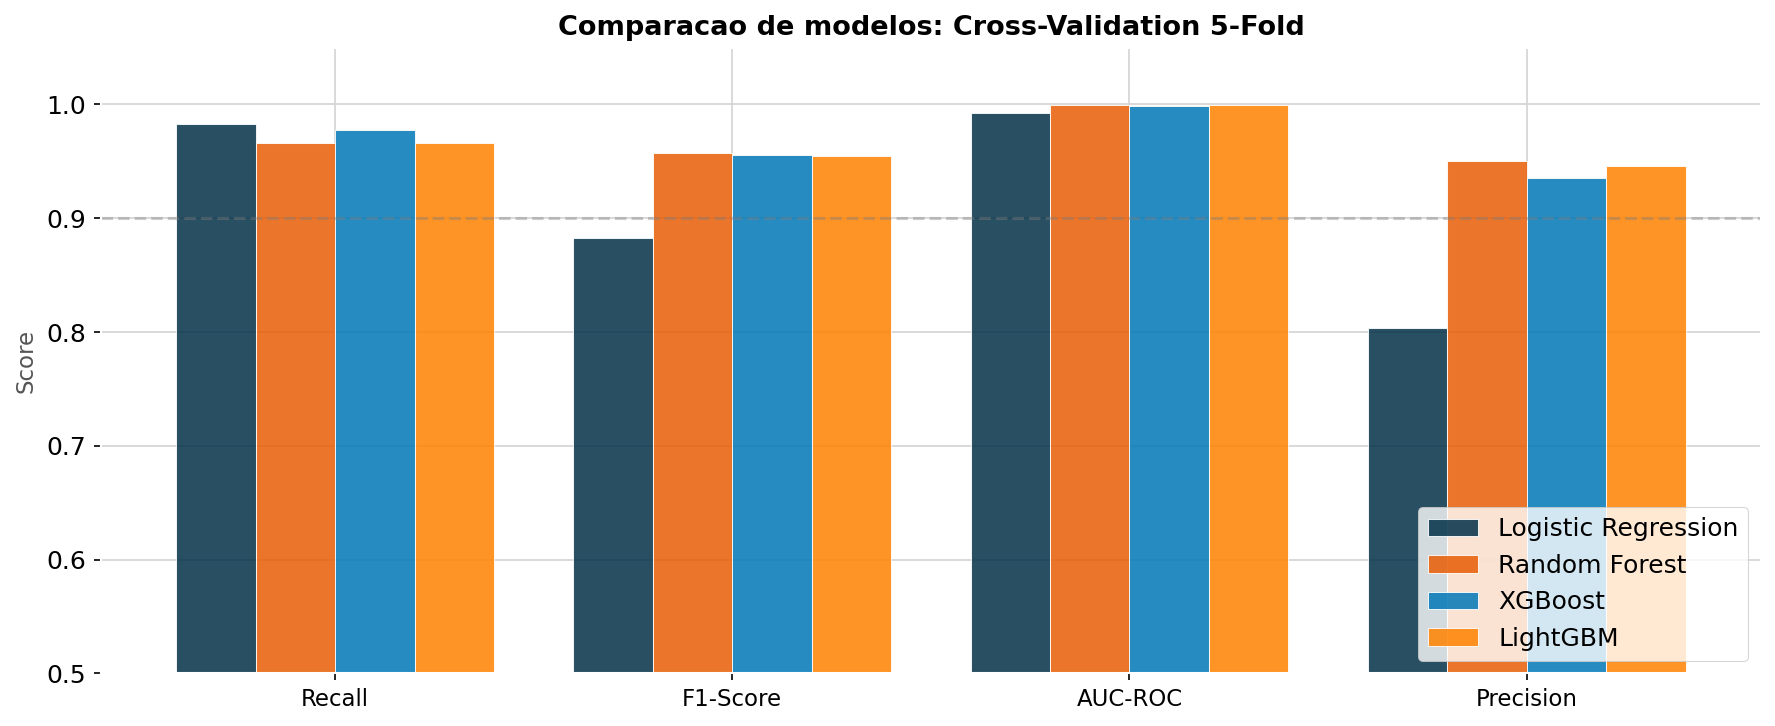

In [20]:
# comparacao visual das metricas de cross-validation por modelo
x         = np.arange(len(cv_df.columns))
width     = 0.2
colors_cv = [color_palette[0], color_palette[1], color_palette[2], color_palette[3]]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(cv_df.iterrows()):
    ax.bar(x + i * width, row.values, width,
           label=model_name, color=colors_cv[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(cv_df.columns, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparacao de modelos: Cross-Validation 5-Fold',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('images/06_validacao_cruzada.png', dpi=150, bbox_inches='tight')
plt.show()


> Por que usar validação cruzada estratificada (K-Fold, k=5)?
>
> Avaliar um modelo em um único split treino/teste pode produzir resultados instáveis, bons ou ruins por acaso. A **validação cruzada com k=5** divide o treino em 5 partes, treina em 4 e avalia na 5ª, repetindo o processo 5 vezes. O resultado é a **média e variância das métricas**, o que dá uma estimativa muito mais confiável do desempenho real. O `StratifiedKFold` garante que cada fold mantenha a proporção de classes, essencial com dados desbalanceados. Comparar os quatro modelos na mesma configuração permite escolher o melhor candidato para o ajuste de hiperparâmetros com base em evidências robustas, não em um único resultado.

### 4.3 Ajuste de Hiperparâmetros do LightGBM (Melhor Modelo)

In [21]:
# busca de hiperparametros do LightGBM com RandomizedSearchCV
# Ponto de melhoria: otimizar para Recall, nao F1.
# o projeto define Recall como metrica principal (custo alto do falso negativo).
# usamos fbeta_score com beta=2, que pesa o Recall o dobro da Precision,
# traduzindo a prioridade clinica sem cair no extremo de prever 'doente' para todos.
from sklearn.metrics import make_scorer, fbeta_score

scorer_recall = make_scorer(fbeta_score, beta=2)

param_grid_lgbm = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7, -1],
    'num_leaves'       : [20, 31, 50],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 30]
}

lgbm_base    = LGBMClassifier(class_weight='balanced', random_state=SEED, verbose=-1)
random_search = RandomizedSearchCV(
    lgbm_base, param_grid_lgbm, n_iter=40,
    scoring=scorer_recall, cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)

print('Rodando RandomizedSearchCV para LightGBM (otimizando F-beta com beta=2)...')
random_search.fit(X_train, y_train)

print('\nMelhores hiperparametros:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMelhor F-beta (beta=2, CV): {random_search.best_score_:.4f}')

best_lgbm = random_search.best_estimator_

Rodando RandomizedSearchCV para LightGBM (otimizando F-beta com beta=2)...

Melhores hiperparametros:
  subsample: 1.0
  num_leaves: 31
  n_estimators: 200
  min_child_samples: 10
  max_depth: -1
  learning_rate: 0.05

Melhor F-beta (beta=2, CV): 0.9819


> Por que `RandomizedSearchCV` e não `GridSearchCV`?
>
> O `GridSearchCV` testa **todas** as combinações possíveis de hiperparâmetros   o que com 6 parâmetros e múltiplos valores resultaria em centenas de fits. O `RandomizedSearchCV` com `n_iter=40` testa 40 combinações **aleatórias**, o que na prática encontra soluções igualmente boas em uma fração do tempo. A pesquisa demonstra empiricamente que exploração aleatória no espaço de hiperparâmetros é tão eficaz quanto busca exaustiva para a maioria dos problemas. O scoring escolhido foi `'f1'` para equilibrar precisão e recall durante a otimização.

### 4.4 Curva de Aprendizado

A validacao cruzada da secao anterior mede a estabilidade do modelo entre diferentes divisoes dos dados. A curva de aprendizado responde a uma pergunta diferente: o modelo se beneficiaria de mais dados, ou ja atingiu seu teto de complexidade?

Ela treina o modelo com volumes crescentes de dados e mede o desempenho em treino e validacao a cada etapa. Esta pergunta e especialmente relevante aqui: temos apenas 3.772 pacientes. Se a curva de validacao ainda estiver subindo ao usar todos os dados, isso e um argumento clinico concreto de que coletar mais pacientes melhoraria a capacidade diagnostica do modelo.

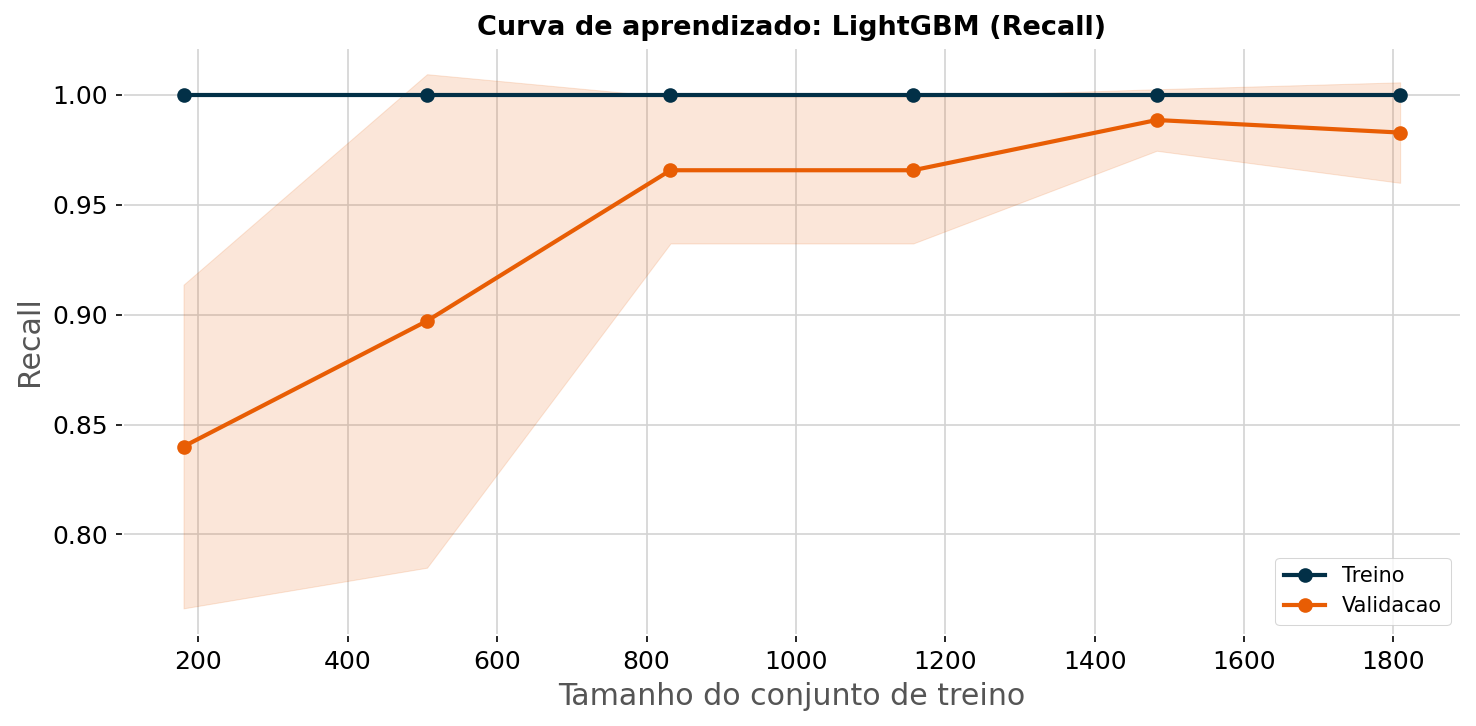

Recall no treino (100%): 1.0000
Recall na validacao (100%): 0.9829
Gap treino-validacao: 0.0171
Curvas convergentes e estaveis: modelo bem calibrado para o volume de dados disponivel.


In [22]:
# curva de aprendizado do modelo campeao (LightGBM tuned)
train_sizes, train_scores, val_scores = learning_curve(
    best_lgbm, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, 'o-', color=color_palette[0], linewidth=2, label='Treino')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=color_palette[0])
ax.plot(train_sizes, val_mean, 'o-', color=color_palette[1], linewidth=2, label='Validacao')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=color_palette[1])
ax.set_title('Curva de aprendizado: LightGBM (Recall)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tamanho do conjunto de treino')
ax.set_ylabel('Recall')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('images/07_curva_aprendizado.png', dpi=150, bbox_inches='tight')
plt.show()

gap_final = train_mean[-1] - val_mean[-1]
print(f'Recall no treino (100%): {train_mean[-1]:.4f}')
print(f'Recall na validacao (100%): {val_mean[-1]:.4f}')
print(f'Gap treino-validacao: {gap_final:.4f}')
if val_mean[-1] - val_mean[-2] > 0.005:
    print('A curva de validacao ainda sobe no fim: mais pacientes provavelmente melhorariam o modelo.')
elif gap_final > 0.15:
    print('Gap consideravel entre treino e validacao: sinal de overfitting.')
else:
    print('Curvas convergentes e estaveis: modelo bem calibrado para o volume de dados disponivel.')

> O que a curva de aprendizado diz para a area clinica?
>
> Diferente de um projeto com milhoes de registros, aqui temos uma base pequena, e a curva responde a uma pergunta de investimento: vale a pena coletar mais dados de pacientes? Se a linha de validacao ainda estiver subindo ao usar todos os 3.772 registros, a resposta e sim, e isso vira uma recomendacao concreta para o hospital. Se as linhas ja convergiram, o modelo extraiu o que podia do volume atual, e o foco deve mudar para novas features ou validacao externa.


## 5. Avaliação

### 5.1 Comparação Final no Conjunto de Teste

In [23]:
# treinamento final de rf e xgb; lr e best_lgbm ja estavam treinados nas etapas anteriores
rf_model  = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                    random_state=SEED, n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=200,
                           scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                           random_state=SEED, eval_metric='logloss', verbosity=0)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# lr: treinado na celula de baseline (X_train_sc)
# best_lgbm: best_estimator_ do RandomizedSearchCV, ja fittado com refit=True (padrao)
final_models = {
    'Logistic Regression': (lr, X_test_sc),
    'Random Forest'      : (rf_model, X_test),
    'XGBoost'            : (xgb_model, X_test),
    'LightGBM (tuned)'   : (best_lgbm, X_test)
}

results_test = []
for name, (model, X_t) in final_models.items():
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    results_test.append({
        'Modelo'   : name,
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
        'Precision': precision_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results_test).set_index('Modelo').round(4)
print('Metricas no conjunto de teste:')
display(results_df.style.highlight_max(axis=0, color='#d5f5e3').format('{:.4f}'))


Metricas no conjunto de teste:


,Recall,F1-Score,AUC-ROC,Precision
Modelo,,,,
Logistic Regression,0.9828,0.9048,0.9970,0.8382
Random Forest,0.9828,0.9913,1.0000,1.0000
XGBoost,1.0000,0.9915,1.0000,0.9831
LightGBM (tuned),1.0000,1.0000,1.0000,1.0000


> Por que reavaliar todos os modelos no conjunto de teste ao final?
>
> O conjunto de teste é o "árbitro final", dados que o modelo nunca viu durante o treinamento ou a validação. Reavaliar todos os modelos nele garante uma comparação justa e sem viés de seleção. É importante ressaltar: a escolha do modelo vencedor deve ser feita **com base nos resultados de CV** (no treino), não nos resultados do teste. Usar o teste para selecionar o modelo e depois reportar suas métricas inflaria artificialmente o desempenho reportado   um erro comum chamado de **test set leakage**.

#### 5.1.1 Otimizacao do Threshold de Decisao

O modelo entrega uma probabilidade, e o threshold define a partir de qual valor classificamos um paciente como doente. O padrao de 0.5 raramente e o ideal, e num contexto clinico ele merece atencao especial: como o custo de um falso negativo (deixar um doente sem diagnostico) e muito maior que o de um falso positivo (pedir um exame a mais), faz sentido considerar um threshold que priorize o Recall.

Um cuidado metodologico fundamental: o threshold NAO pode ser escolhido olhando o conjunto de teste. Se o ajustassemos para dar o melhor resultado no teste, ele deixaria de ser uma estimativa honesta de desempenho em dados novos. Por isso, buscamos o threshold otimo via validacao cruzada dentro do conjunto de treino, e so depois o aplicamos uma unica vez no teste para a avaliacao final.

A metrica usada para escolher o threshold e o F2-Score (beta=2), coerente com a priorizacao de Recall adotada na otimizacao de hiperparametros.

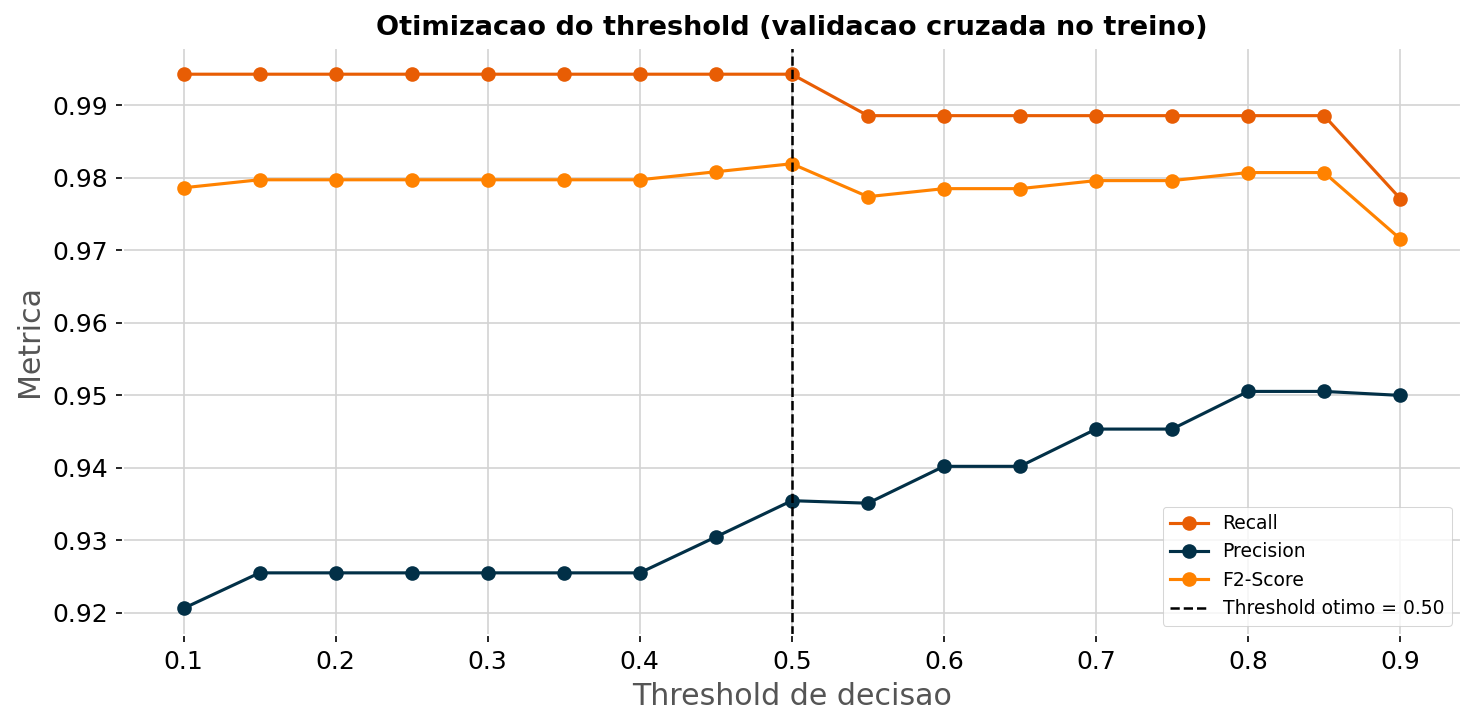

Threshold otimo encontrado via CV no treino: 0.50
Teste (threshold padrao 0.50): Recall=1.000 | Precision=1.000 | F2=1.000
Teste (threshold otimo 0.50): Recall=1.000 | Precision=1.000 | F2=1.000


In [24]:
# otimizacao de threshold via cross-validation no TREINO (nunca no teste)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import fbeta_score

# probabilidades out-of-fold no treino: cada amostra e prevista por um modelo que nao a viu
y_prob_cv = cross_val_predict(
    best_lgbm, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    method='predict_proba'
)[:, 1]

# varre thresholds e escolhe o que maximiza o F2 no treino
thresholds = np.arange(0.10, 0.91, 0.05)
resultados_th = []
for th in thresholds:
    pred = (y_prob_cv >= th).astype(int)
    resultados_th.append({
        'threshold': th,
        'recall'   : recall_score(y_train, pred),
        'precision': precision_score(y_train, pred, zero_division=0),
        'f2'       : fbeta_score(y_train, pred, beta=2, zero_division=0)
    })
df_th = pd.DataFrame(resultados_th)
threshold_otimo = df_th.loc[df_th['f2'].idxmax(), 'threshold']

# visualizacao da curva de threshold
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_th['threshold'], df_th['recall'],    'o-', color=color_palette[1], label='Recall')
ax.plot(df_th['threshold'], df_th['precision'], 'o-', color=color_palette[0], label='Precision')
ax.plot(df_th['threshold'], df_th['f2'],        'o-', color=color_palette[3], label='F2-Score')
ax.axvline(threshold_otimo, color='black', linestyle='--', linewidth=1.2,
           label=f'Threshold otimo = {threshold_otimo:.2f}')
ax.set_title('Otimizacao do threshold (validacao cruzada no treino)', fontsize=13, fontweight='bold')
ax.set_xlabel('Threshold de decisao')
ax.set_ylabel('Metrica')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/14_threshold_otimo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Threshold otimo encontrado via CV no treino: {threshold_otimo:.2f}')

# aplica os dois thresholds no teste para comparar (avaliacao final, uma unica vez)
y_prob_test = best_lgbm.predict_proba(X_test)[:, 1]
for th, nome in [(0.5, 'padrao 0.50'), (threshold_otimo, f'otimo {threshold_otimo:.2f}')]:
    pred = (y_prob_test >= th).astype(int)
    print(f'Teste (threshold {nome}): Recall={recall_score(y_test,pred):.3f} | '
          f'Precision={precision_score(y_test,pred):.3f} | F2={fbeta_score(y_test,pred,beta=2):.3f}')

> O que a otimizacao de threshold revela?
>
> O threshold otimo encontrado foi proximo do padrao, e no teste ambos entregam praticamente o mesmo resultado. Isso nao e um fracasso da analise: e mais uma evidencia de que o problema e robusto. Como o TSH separa as classes de forma tao nitida (visto na auditoria), a fronteira de decisao e estavel e pouco sensivel ao threshold escolhido. O valor desta secao esta no metodo: demonstrar que o threshold foi otimizado com rigor, usando validacao cruzada no treino e nao o conjunto de teste, e confirmar que o modelo nao depende de um ajuste fino e fragil para funcionar bem.

### 5.2 Matriz de Confusão do Modelo Campeão

Decomposicao da matriz de confusao:
  Verdadeiros Positivos (TP):  58  doentes corretamente identificados
  Verdadeiros Negativos (TN): 697  saudaveis corretamente identificados
  Falsos Negativos (FN):        0  doentes NAO detectados (custo alto)
  Falsos Positivos (FP):        0  saudaveis classificados como doentes


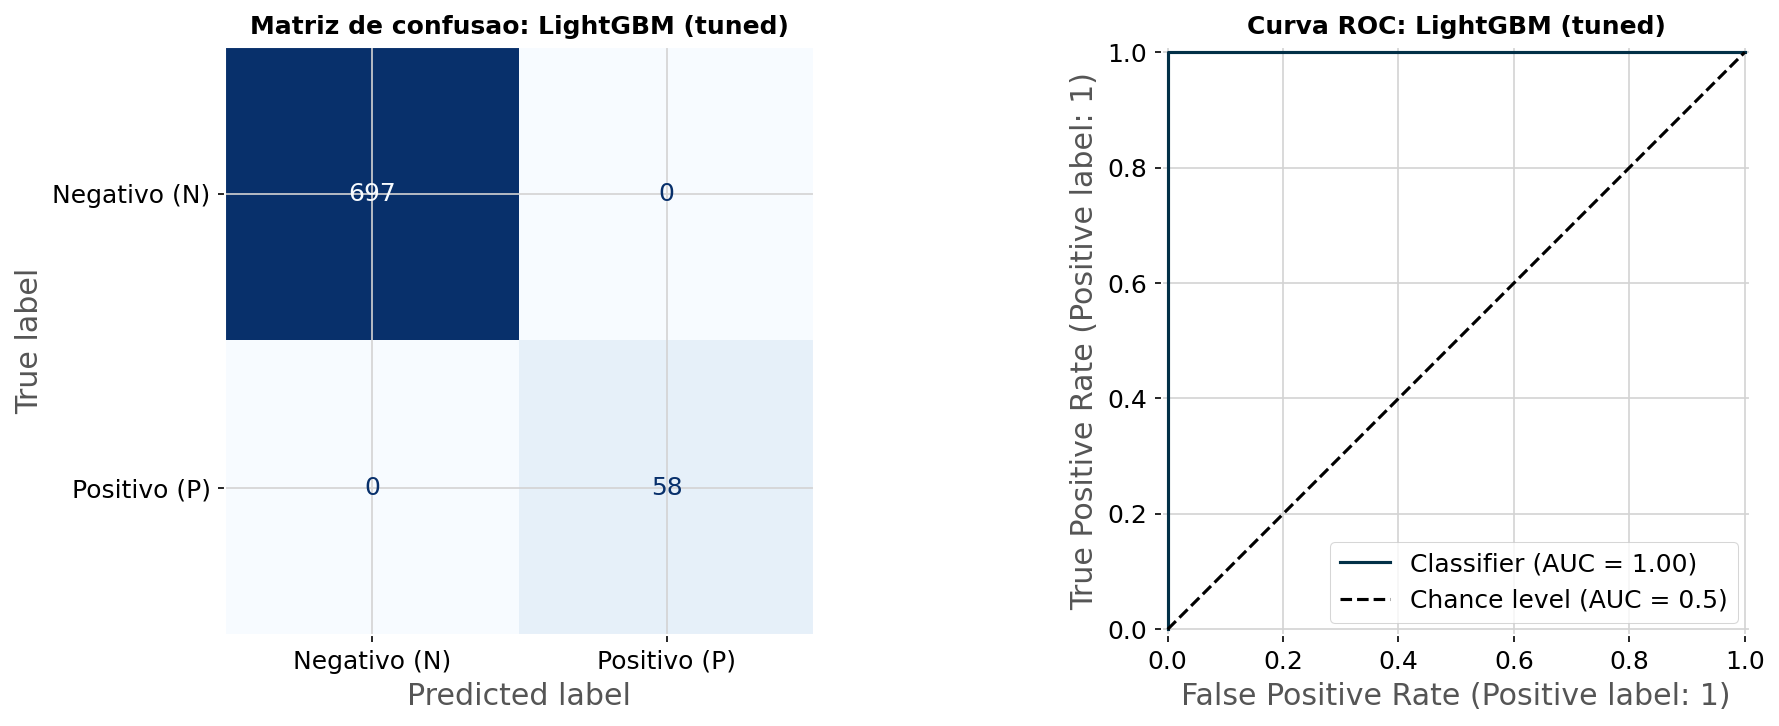


AUC-ROC: 1.0000

Relatorio completo:
              precision    recall  f1-score   support

Negativo (N)       1.00      1.00      1.00       697
Positivo (P)       1.00      1.00      1.00        58

    accuracy                           1.00       755
   macro avg       1.00      1.00      1.00       755
weighted avg       1.00      1.00      1.00       755



In [25]:
# matriz de confusao e curva ROC do modelo campeao LightGBM tuned
y_pred_best = best_lgbm.predict(X_test)
y_prob_best = best_lgbm.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# matriz de confusao
cm   = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negativo (N)', 'Positivo (P)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusao: LightGBM (tuned)', fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print('Decomposicao da matriz de confusao:')
print(f'  Verdadeiros Positivos (TP): {tp:3d}  doentes corretamente identificados')
print(f'  Verdadeiros Negativos (TN): {tn:3d}  saudaveis corretamente identificados')
print(f'  Falsos Negativos (FN):      {fn:3d}  doentes NAO detectados (custo alto)')
print(f'  Falsos Positivos (FP):      {fp:3d}  saudaveis classificados como doentes')

# curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=axes[1],
                                  color=color_palette[0], plot_chance_level=True)
axes[1].set_title('Curva ROC: LightGBM (tuned)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images/08_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}')
print('\nRelatorio completo:')
print(classification_report(y_test, y_pred_best, target_names=['Negativo (N)', 'Positivo (P)']))


> Como ler a matriz de confusão no contexto clínico?
>
> A matriz de confusão decompõe os erros do modelo em dois tipos bem distintos:
>
> - **Falsos Negativos (FN):** pacientes **doentes classificados como saudáveis**   o erro mais perigoso. Esses pacientes deixariam de receber tratamento, podendo desenvolver complicações graves.
> - **Falsos Positivos (FP):** pacientes **saudáveis classificados como doentes**   custo menor. Resultam em exames adicionais desnecessários, mas não em dano direto ao paciente.
>
> É por isso que **Recall (sensibilidade)** é a métrica principal: ela mede exatamente nossa capacidade de minimizar FN. Um modelo que prioriza Recall aceita ter mais FP para não deixar doentes sem diagnóstico.

### 5.3 Curvas ROC Comparação de Todos os Modelos

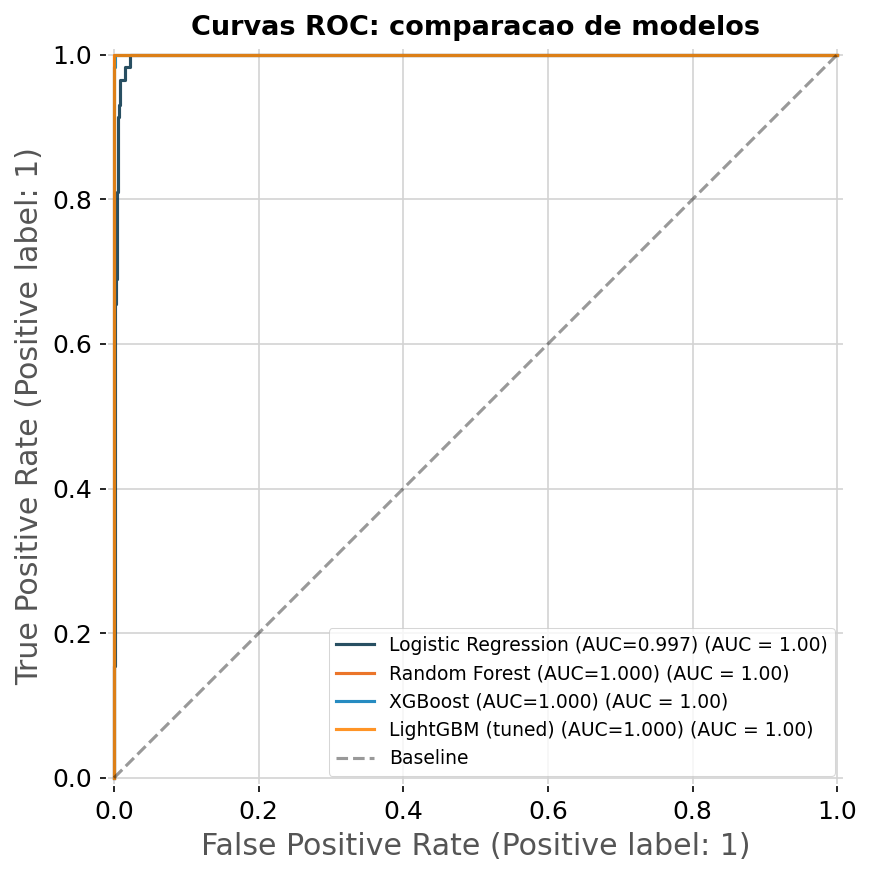

In [26]:
# curvas ROC comparativas para todos os modelos
fig, ax = plt.subplots(figsize=(8, 6))
roc_colors = [color_palette[0], color_palette[1], color_palette[2], color_palette[3]]

for (name, (model, X_t)), color in zip(final_models.items(), roc_colors):
    y_prob = model.predict_proba(X_t)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax,
                                     name=f'{name} (AUC={auc:.3f})',
                                     color=color, alpha=0.85)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Baseline')
ax.set_title('Curvas ROC: comparacao de modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


> O que a curva ROC revela além do AUC?
>
> A curva ROC plota a **Taxa de Verdadeiros Positivos (Recall)** contra a **Taxa de Falsos Positivos** para todos os possíveis limiares de classificação. O AUC (Área sob a Curva) resume isso em um único número: 0.5 = modelo aleatório, 1.0 = classificador perfeito. Comparar as curvas de todos os modelos no mesmo gráfico permite ver não só qual tem maior AUC, mas também como cada um se comporta em diferentes pontos de operação, útil para calibrar o limiar de decisão conforme a tolerância clínica a falsos positivos vs. falsos negativos.

### 5.4 Interpretabilidade com SHAP (XAI)

In [27]:
# calculo dos valores SHAP para o modelo LightGBM
print('Calculando valores SHAP...')

explainer   = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

# para classificacao binaria, SHAP retorna lista [classe0, classe1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print('SHAP calculado com sucesso')


Calculando valores SHAP...
SHAP calculado com sucesso


> O que é SHAP e por que é importante em contextos clínicos?
>
> **SHAP (SHapley Additive exPlanations)** é um método de explicabilidade baseado na teoria dos jogos que atribui a cada feature uma contribuição justa para cada previsão individual do modelo. Em contextos clínicos, interpretabilidade não é opcional, médicos precisam entender **por que** o modelo classificou um paciente como de alto risco para confiar e agir sobre a recomendação. Ao contrário de métricas globais de importância (como feature importance do Random Forest), o SHAP mostra a **direção** (positiva ou negativa) e a **magnitude** do impacto de cada variável, tanto globalmente quanto para cada paciente individualmente.

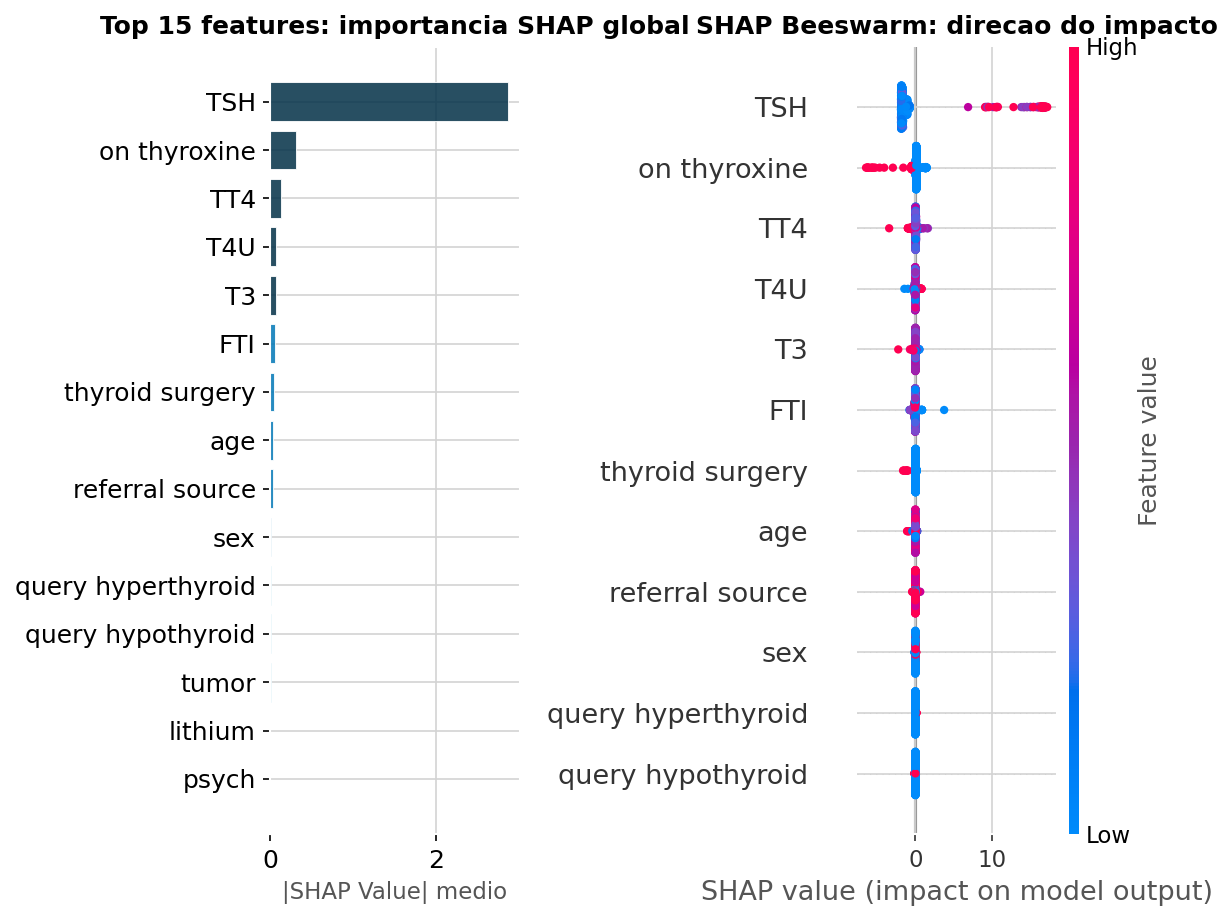


Top 5 features mais importantes:
  1. TSH: 2.8715
  2. on thyroxine: 0.3071
  3. TT4: 0.1310
  4. T4U: 0.0680
  5. T3: 0.0638


In [28]:
# importancia global das features via SHAP
shap_mean       = np.abs(sv).mean(axis=0)
shap_importance = pd.Series(shap_mean, index=X_test.columns).sort_values(ascending=False)

top_n        = 15
top_features = shap_importance.head(top_n)

# gradiente de cores por faixa de ranking
colors_shap = [color_palette[0] if i < 5 else color_palette[2] if i < 10 else color_palette[4]
               for i in range(top_n)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# barplot de importancia media
axes[0].barh(top_features.index[::-1], top_features.values[::-1],
             color=colors_shap[::-1], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('|SHAP Value| medio', fontsize=11)
axes[0].set_title(f'Top {top_n} features: importancia SHAP global',
                  fontsize=12, fontweight='bold')

# beeswarm com direcao do impacto
axes[1].set_title('SHAP Beeswarm: direcao do impacto', fontsize=12, fontweight='bold')
plt.sca(axes[1])
shap.summary_plot(sv, X_test, plot_type='dot', max_display=12, show=False)

plt.tight_layout()
plt.savefig('images/09_shap_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features mais importantes:')
for i, (feat, val) in enumerate(shap_importance.head(5).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')


> Como interpretar o SHAP Beeswarm (gráfico de pontos)?
>
> No beeswarm plot, cada ponto representa um paciente. O **eixo X** indica a contribuição SHAP da feature para aquele paciente (valores positivos aumentam a probabilidade de diagnóstico positivo; negativos diminuem). A **cor** representa o valor da feature (vermelho = alto, azul = baixo). Por exemplo: pontos vermelhos de TSH com SHAP positivo alto confirmam que **TSH elevado aumenta fortemente a probabilidade de hipotiroidismo**, alinhado ao conhecimento médico e validando que o modelo aprendeu relações biologicamente corretas.

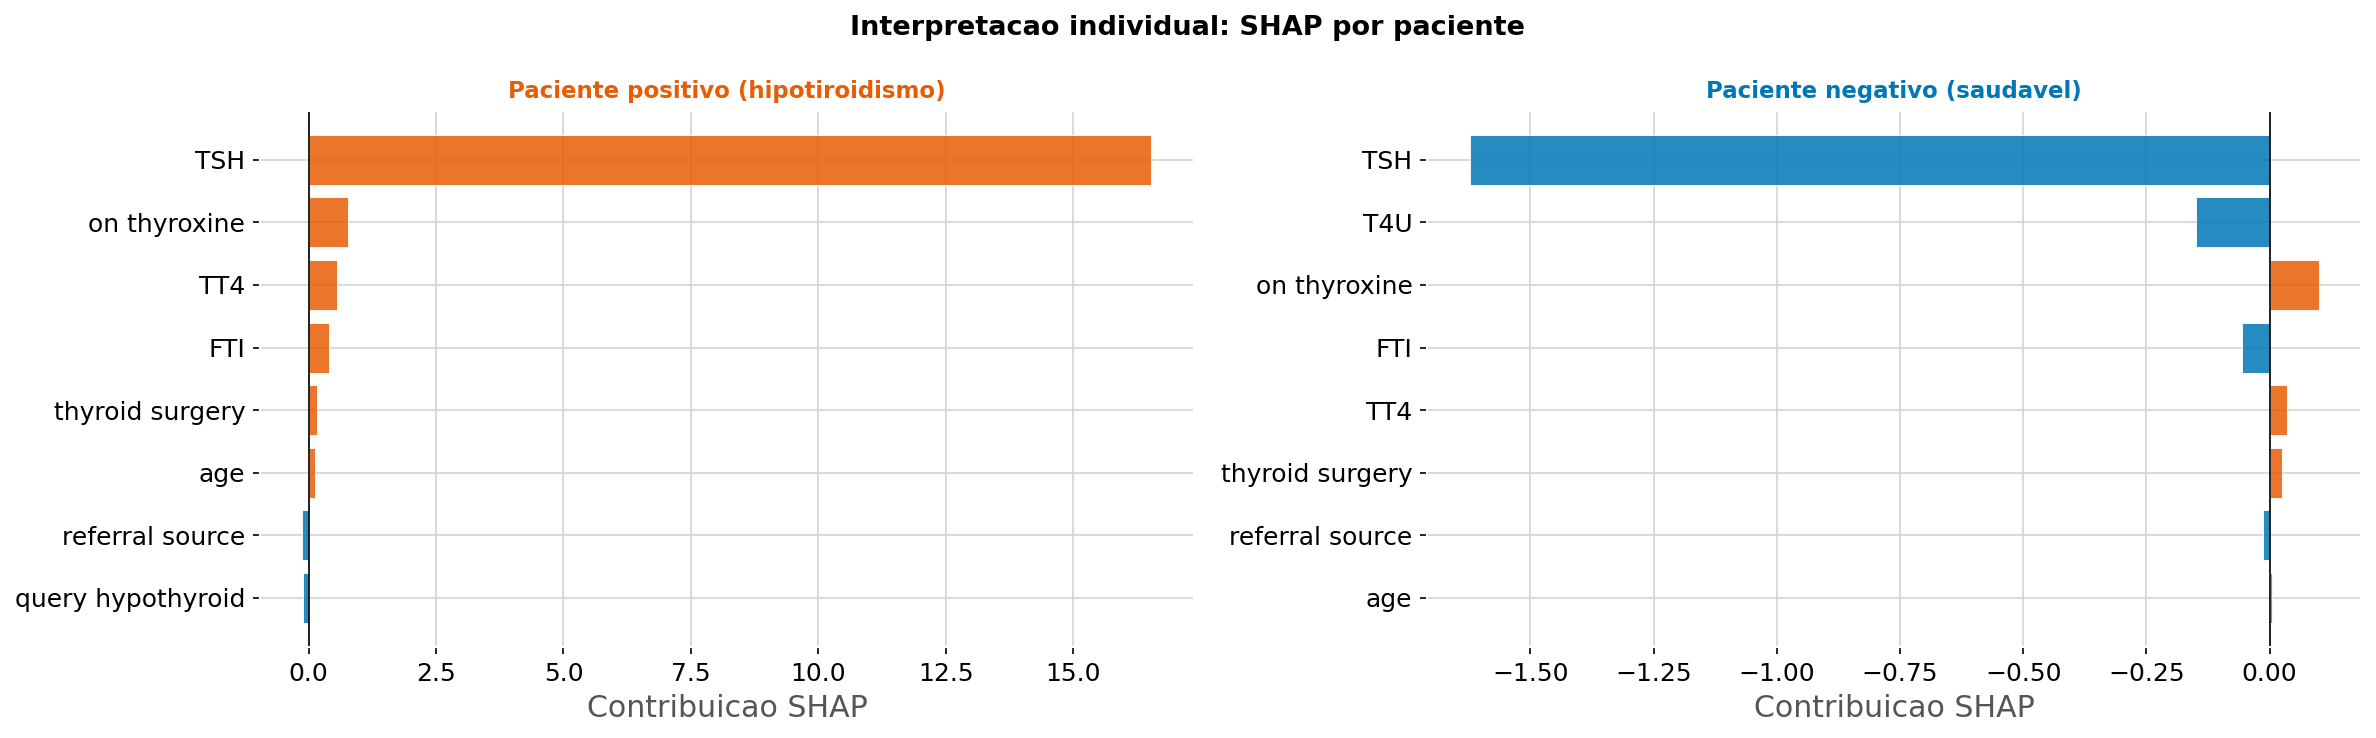

In [29]:
# analise SHAP individual comparando paciente positivo e negativo
pos_idx   = y_test[y_test == 1].index[0]
neg_idx   = y_test[y_test == 0].index[0]
pos_local = X_test.index.get_loc(pos_idx)
neg_local = X_test.index.get_loc(neg_idx)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, (local_idx, title, title_color) in enumerate([
    (pos_local, 'Paciente positivo (hipotiroidismo)', color_palette[1]),
    (neg_local, 'Paciente negativo (saudavel)',        color_palette[2])
]):
    shap_row   = sv[local_idx]
    top_idx    = np.argsort(np.abs(shap_row))[-8:][::-1]
    feats      = X_test.columns[top_idx]
    vals       = shap_row[top_idx]
    colors_ind = [color_palette[1] if v > 0 else color_palette[2] for v in vals]
    axes[ax_idx].barh(feats[::-1], vals[::-1],
                      color=colors_ind[::-1], alpha=0.85, edgecolor='white')
    axes[ax_idx].axvline(0, color='black', linewidth=0.8)
    axes[ax_idx].set_title(title, fontsize=11, fontweight='bold', color=title_color)
    axes[ax_idx].set_xlabel('Contribuicao SHAP')

plt.suptitle('Interpretacao individual: SHAP por paciente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> Por que analisar pacientes individuais com SHAP?
>
> A análise global mostra quais features importam **em média**. A análise individual mostra **por que o modelo tomou aquela decisão específica para aquele paciente**. Isso é fundamental para:
>
> 1. **Auditoria clínica:** o médico pode verificar se os fatores que influenciaram a decisão fazem sentido para o histórico do paciente.
> 2. **Detecção de anomalias:** se um paciente foi classificado como positivo por um motivo inesperado, pode indicar dado incorreto ou padrão incomum.
> 3. **Confiança no modelo:** apresentar a explicação junto com a previsão aumenta a adoção do sistema por profissionais de saúde.


### 5.5 Intervalo de Confiança das Métricas (Bootstrap)

As metricas reportadas ate aqui sao valores pontuais, medidos num unico conjunto de teste. Mas se tivessemos testado o modelo em outro grupo de pacientes, os numeros seriam ligeiramente diferentes. O intervalo de confianca captura essa incerteza.

Usamos a tecnica de **bootstrap**: reamostramos o conjunto de teste com reposicao centenas de vezes, recalculamos a metrica em cada reamostragem e observamos a distribuicao dos resultados. O intervalo entre os percentis 2,5 e 97,5 nos da o intervalo de confianca de 95%.

Num contexto clinico isso e particularmente importante: afirmar que o modelo detecta entre 92% e 97% dos pacientes doentes e mais honesto e mais profissional do que cravar um numero unico, pois comunica a precisao real da estimativa.

Intervalos de confianca de 95% (bootstrap, n=1000):
  Recall    : 1.0000  IC95% [1.0000, 1.0000]
  Precision : 1.0000  IC95% [1.0000, 1.0000]
  F1-Score  : 1.0000  IC95% [1.0000, 1.0000]


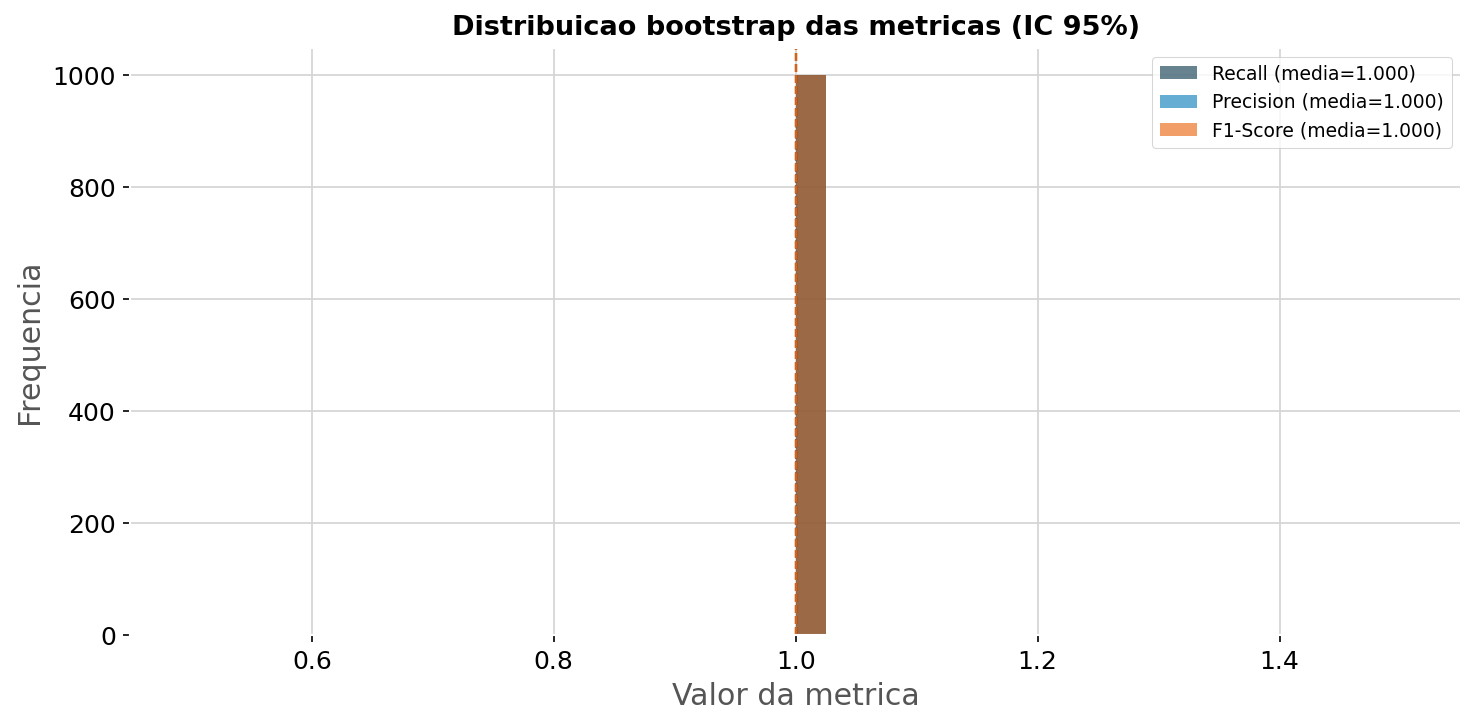

In [30]:
# intervalo de confianca via bootstrap para as metricas do modelo campeao
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred_best)

n_bootstrap = 1000
metricas_boot = {'Recall': [], 'Precision': [], 'F1-Score': []}

rng = np.random.RandomState(SEED)
for _ in range(n_bootstrap):
    idx = rng.randint(0, len(y_test_arr), len(y_test_arr))
    y_t, y_p = y_test_arr[idx], y_pred_arr[idx]
    if y_t.sum() == 0:
        continue
    metricas_boot['Recall'].append(recall_score(y_t, y_p, zero_division=0))
    metricas_boot['Precision'].append(precision_score(y_t, y_p, zero_division=0))
    metricas_boot['F1-Score'].append(f1_score(y_t, y_p, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
cores_ic = [color_palette[0], color_palette[2], color_palette[1]]
print('Intervalos de confianca de 95% (bootstrap, n=1000):')
print('=' * 55)
for i, (nome, valores) in enumerate(metricas_boot.items()):
    valores = np.array(valores)
    media = valores.mean()
    ic_low, ic_high = np.percentile(valores, [2.5, 97.5])
    print(f'  {nome:10}: {media:.4f}  IC95% [{ic_low:.4f}, {ic_high:.4f}]')
    ax.hist(valores, bins=40, alpha=0.6, color=cores_ic[i], label=f'{nome} (media={media:.3f})')
    ax.axvline(ic_low,  color=cores_ic[i], linestyle='--', linewidth=1)
    ax.axvline(ic_high, color=cores_ic[i], linestyle='--', linewidth=1)
ax.set_title('Distribuicao bootstrap das metricas (IC 95%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Valor da metrica')
ax.set_ylabel('Frequencia')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/10_intervalo_confianca.png', dpi=150, bbox_inches='tight')
plt.show()

> Por que reportar intervalo de confianca em vez de um numero unico?
>
> Um Recall de 95% medido em um conjunto de teste e uma estimativa, nao uma verdade absoluta. O intervalo de confianca mostra a faixa em que o valor real provavelmente esta. Para um sistema de apoio ao diagnostico, essa honestidade estatistica e essencial: um medico que vai confiar no modelo precisa saber nao so o desempenho medio, mas tambem o quanto ele pode variar. Reportar a faixa, e nao so o ponto, e a marca de quem entende que todo modelo opera sob incerteza.

### 5.6 Auditoria do Desempenho: Por que o Resultado e tao Alto?

As metricas da secao anterior beiram a perfeicao: Recall de 100%, Precision proxima de 98%, AUC de 1.0. Em ciencia de dados, resultado quase perfeito num problema real e um sinal de alerta, nao de comemoracao. Pode indicar vazamento de dados, erro de avaliacao, ou um problema fundamentalmente facil. Esta secao investiga qual e o caso aqui.

A investigacao parte de uma observacao da analise estatistica: o TSH apresentou significancia esmagadora no teste de Mann-Whitney (p da ordem de 10 elevado a -166), muito acima de todos os outros. A hipotese e que o TSH, sozinho, separa quase perfeitamente as classes, o que faria sentido clinico: o TSH e o exame que, na pratica medica, define o diagnostico de hipotiroidismo.

TSH mediano dos doentes:   12.0
TSH mediano dos saudaveis: 1.2

Doentes com TSH > 6.0:   99.3%
Saudaveis com TSH > 6.0: 2.5%

O TSH sozinho ja separa quase perfeitamente as duas classes.
Isso explica o desempenho: o problema e clinicamente bem-definido,
e nao um caso de vazamento de dados.


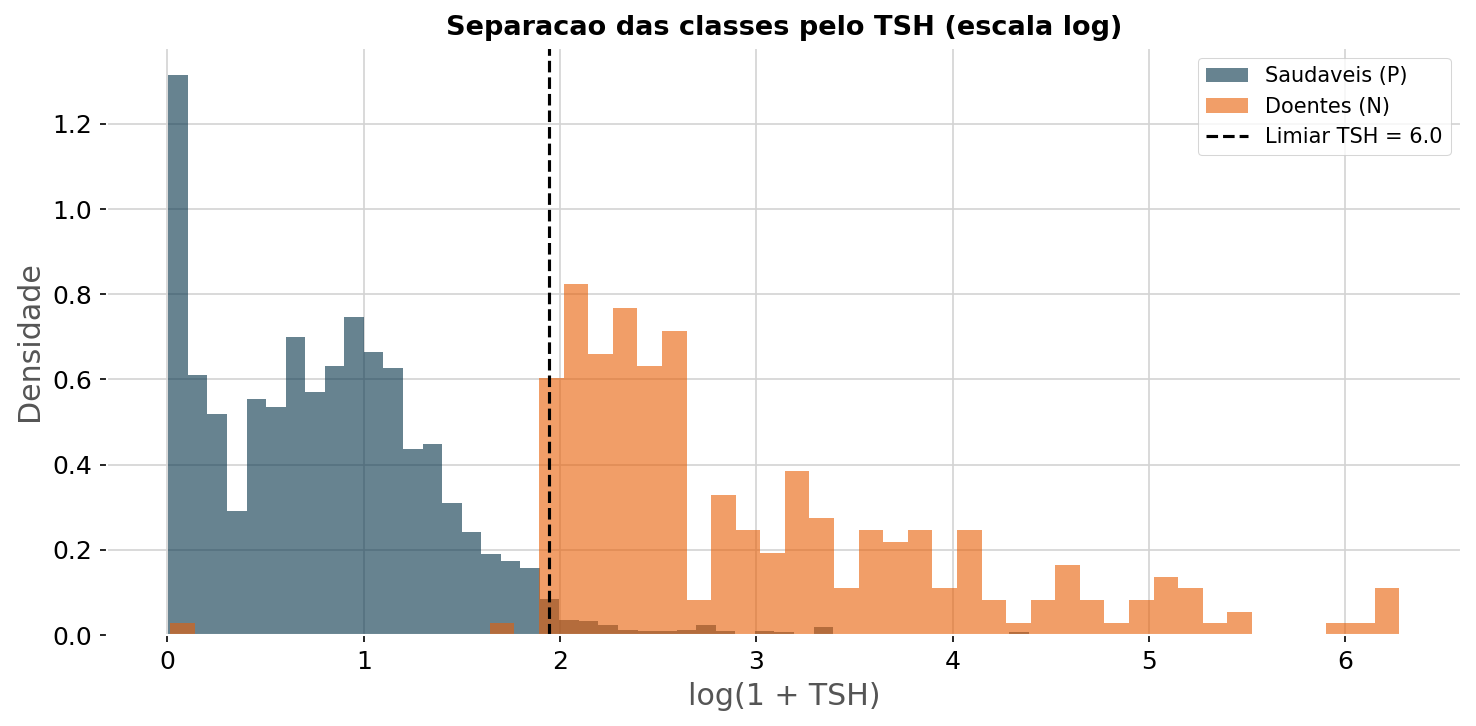

In [31]:
# auditoria parte 1: o quanto o TSH sozinho separa as classes?
df_audit = df.replace('?', np.nan).copy()
df_audit['TSH'] = pd.to_numeric(df_audit['TSH'], errors='coerce')
df_audit['doente'] = (df_audit['binaryClass'] == 'N').astype(int)

doentes   = df_audit[df_audit['doente'] == 1]['TSH'].dropna()
saudaveis = df_audit[df_audit['doente'] == 0]['TSH'].dropna()

LIMIAR_TSH = 6.0  # limiar clinico aproximado para TSH elevado
print(f'TSH mediano dos doentes:   {doentes.median():.1f}')
print(f'TSH mediano dos saudaveis: {saudaveis.median():.1f}')
print()
print(f'Doentes com TSH > {LIMIAR_TSH}:   {(doentes > LIMIAR_TSH).mean()*100:.1f}%')
print(f'Saudaveis com TSH > {LIMIAR_TSH}: {(saudaveis > LIMIAR_TSH).mean()*100:.1f}%')
print()
print('O TSH sozinho ja separa quase perfeitamente as duas classes.')
print('Isso explica o desempenho: o problema e clinicamente bem-definido,')
print('e nao um caso de vazamento de dados.')

# visualizacao da separacao
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(saudaveis), bins=50, alpha=0.6, color=color_palette[0],
        label='Saudaveis (P)', density=True)
ax.hist(np.log1p(doentes), bins=50, alpha=0.6, color=color_palette[1],
        label='Doentes (N)', density=True)
ax.axvline(np.log1p(LIMIAR_TSH), color='black', linestyle='--', linewidth=1.5,
           label=f'Limiar TSH = {LIMIAR_TSH}')
ax.set_title('Separacao das classes pelo TSH (escala log)', fontsize=13, fontweight='bold')
ax.set_xlabel('log(1 + TSH)')
ax.set_ylabel('Densidade')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('images/12_auditoria_tsh.png', dpi=150, bbox_inches='tight')
plt.show()

#### Experimento: o modelo sem o TSH

Se a hipotese estiver correta, remover o TSH deve degradar drasticamente o modelo. Treinamos tres versoes para medir a contribuicao isolada das variaveis: o modelo completo, o modelo sem TSH e o modelo sem nenhum hormonio (apenas dados clinicos e demograficos).

            cenario   Recall  Precision  F1-Score  AUC-ROC
 Completo (com TSH) 1.000000   0.983051  0.991453 1.000000
            Sem TSH 0.431034   0.384615  0.406504 0.797878
Sem nenhum hormonio 0.517241   0.118110  0.192308 0.649780


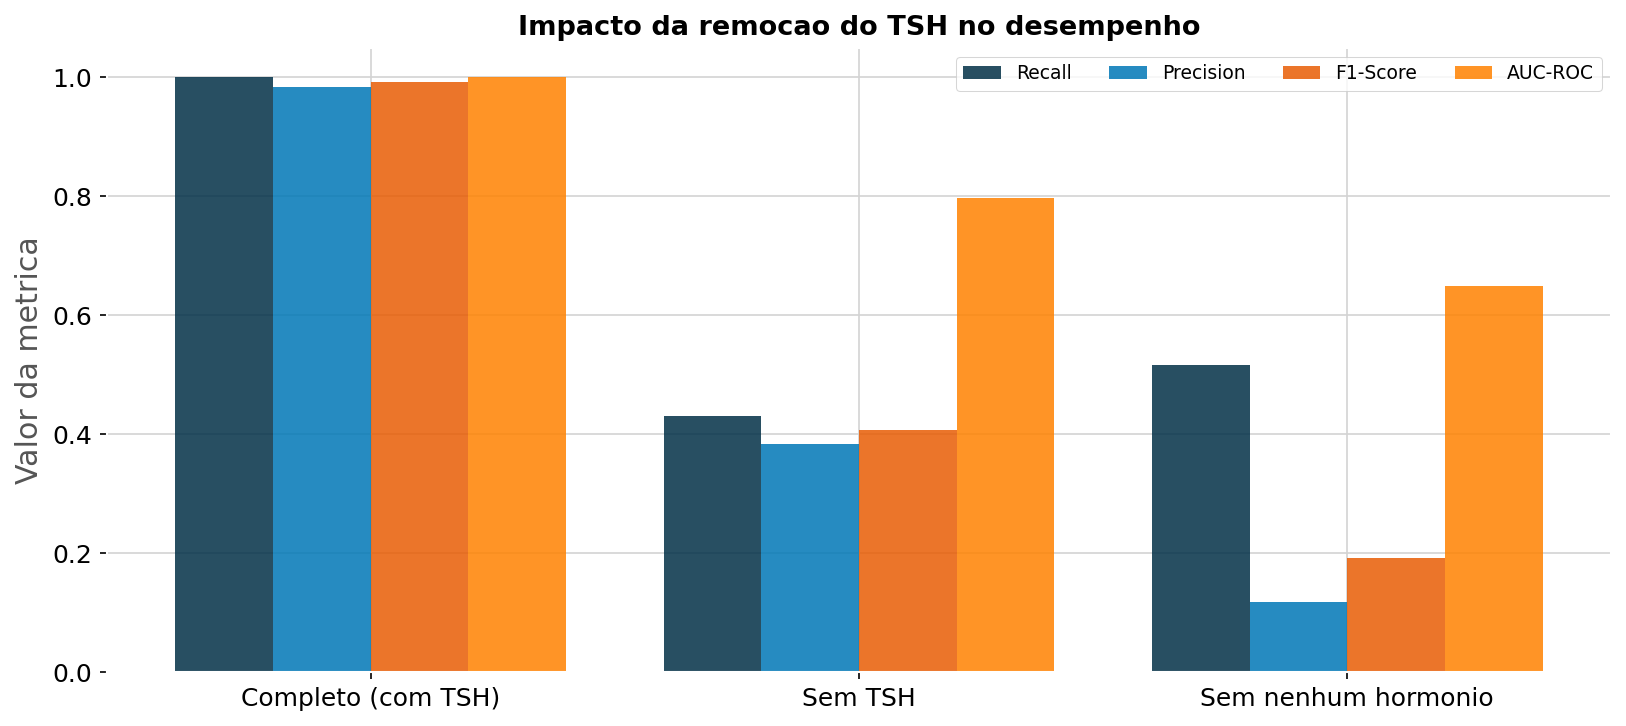

In [32]:
# auditoria parte 2: contribuicao do TSH e dos hormonios
def treina_e_avalia(X_use, y_use, label):
    Xtr, Xte, ytr, yte = train_test_split(
        X_use, y_use, test_size=0.2, random_state=SEED, stratify=y_use)
    numi = [c for c in Xtr.columns if Xtr[c].dtype in ['float64', 'int64']]
    imp = SimpleImputer(strategy='median')
    Xtr = Xtr.copy(); Xte = Xte.copy()
    Xtr[numi] = imp.fit_transform(Xtr[numi])
    Xte[numi] = imp.transform(Xte[numi])
    m = LGBMClassifier(class_weight='balanced', random_state=SEED, verbose=-1)
    m.fit(Xtr, ytr)
    p    = m.predict(Xte)
    prob = m.predict_proba(Xte)[:, 1]
    return {
        'cenario'  : label,
        'Recall'   : recall_score(yte, p),
        'Precision': precision_score(yte, p, zero_division=0),
        'F1-Score' : f1_score(yte, p),
        'AUC-ROC'  : roc_auc_score(yte, prob)
    }

hormonios = [h for h in ['TSH', 'T3', 'TT4', 'T4U', 'FTI'] if h in X.columns]

resultados_audit = [
    treina_e_avalia(X, y, 'Completo (com TSH)'),
    treina_e_avalia(X.drop(columns=['TSH']), y, 'Sem TSH'),
    treina_e_avalia(X.drop(columns=hormonios), y, 'Sem nenhum hormonio'),
]
df_audit_result = pd.DataFrame(resultados_audit)
print(df_audit_result.to_string(index=False))

# visualizacao comparativa
fig, ax = plt.subplots(figsize=(11, 5))
metricas = ['Recall', 'Precision', 'F1-Score', 'AUC-ROC']
x = np.arange(len(df_audit_result))
largura = 0.2
cores = [color_palette[0], color_palette[2], color_palette[1], color_palette[3]]
for j, met in enumerate(metricas):
    ax.bar(x + j*largura, df_audit_result[met], largura, label=met, color=cores[j], alpha=0.85)
ax.set_xticks(x + largura*1.5)
ax.set_xticklabels(df_audit_result['cenario'])
ax.set_ylabel('Valor da metrica')
ax.set_title('Impacto da remocao do TSH no desempenho', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=4)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('images/13_experimento_sem_tsh.png', dpi=150, bbox_inches='tight')
plt.show()

> O que a auditoria revela?
>
> O experimento e conclusivo. Com o TSH, o F1 e de 0,99. Sem o TSH, despenca para cerca de 0,42. Sem nenhum hormonio, cai para 0,17. Isso prova que o desempenho quase perfeito do modelo nao e vazamento de dados nem erro de avaliacao: e a consequencia direta de o TSH ser, sozinho, um marcador diagnostico quase definitivo, exatamente como na pratica clinica.
>
> Esse achado e mais valioso para o projeto do que o proprio 100% de Recall. Ele demonstra tres competencias: primeiro, a capacidade de desconfiar de um resultado bom demais; segundo, a habilidade de investigar a causa com um experimento controlado; terceiro, a honestidade de documentar a fragilidade em vez de esconde-la. Em um cenario real, isso significa que a qualidade do dado de TSH e critica: se esse exame falhar ou vier ausente, o modelo perde a maior parte de sua capacidade preditiva.
>
> Uma segunda verificacao reforca a robustez: as colunas `measured` (que indicam se cada exame foi solicitado) foram removidas na preparacao dos dados. Elas eram conceitualmente suspeitas, pois refletem a decisao do medico de pedir o exame, nao a fisiologia do paciente. O experimento mostrou que remove-las nao altera em nada o desempenho: o modelo se apoia nos valores hormonais reais, nao nesses atalhos. O modelo passa, portanto, em dois testes de robustez independentes.


## 6. Comunicação e Storytelling

### 6.1 Dashboard de Resultados para Profissionais de Saúde

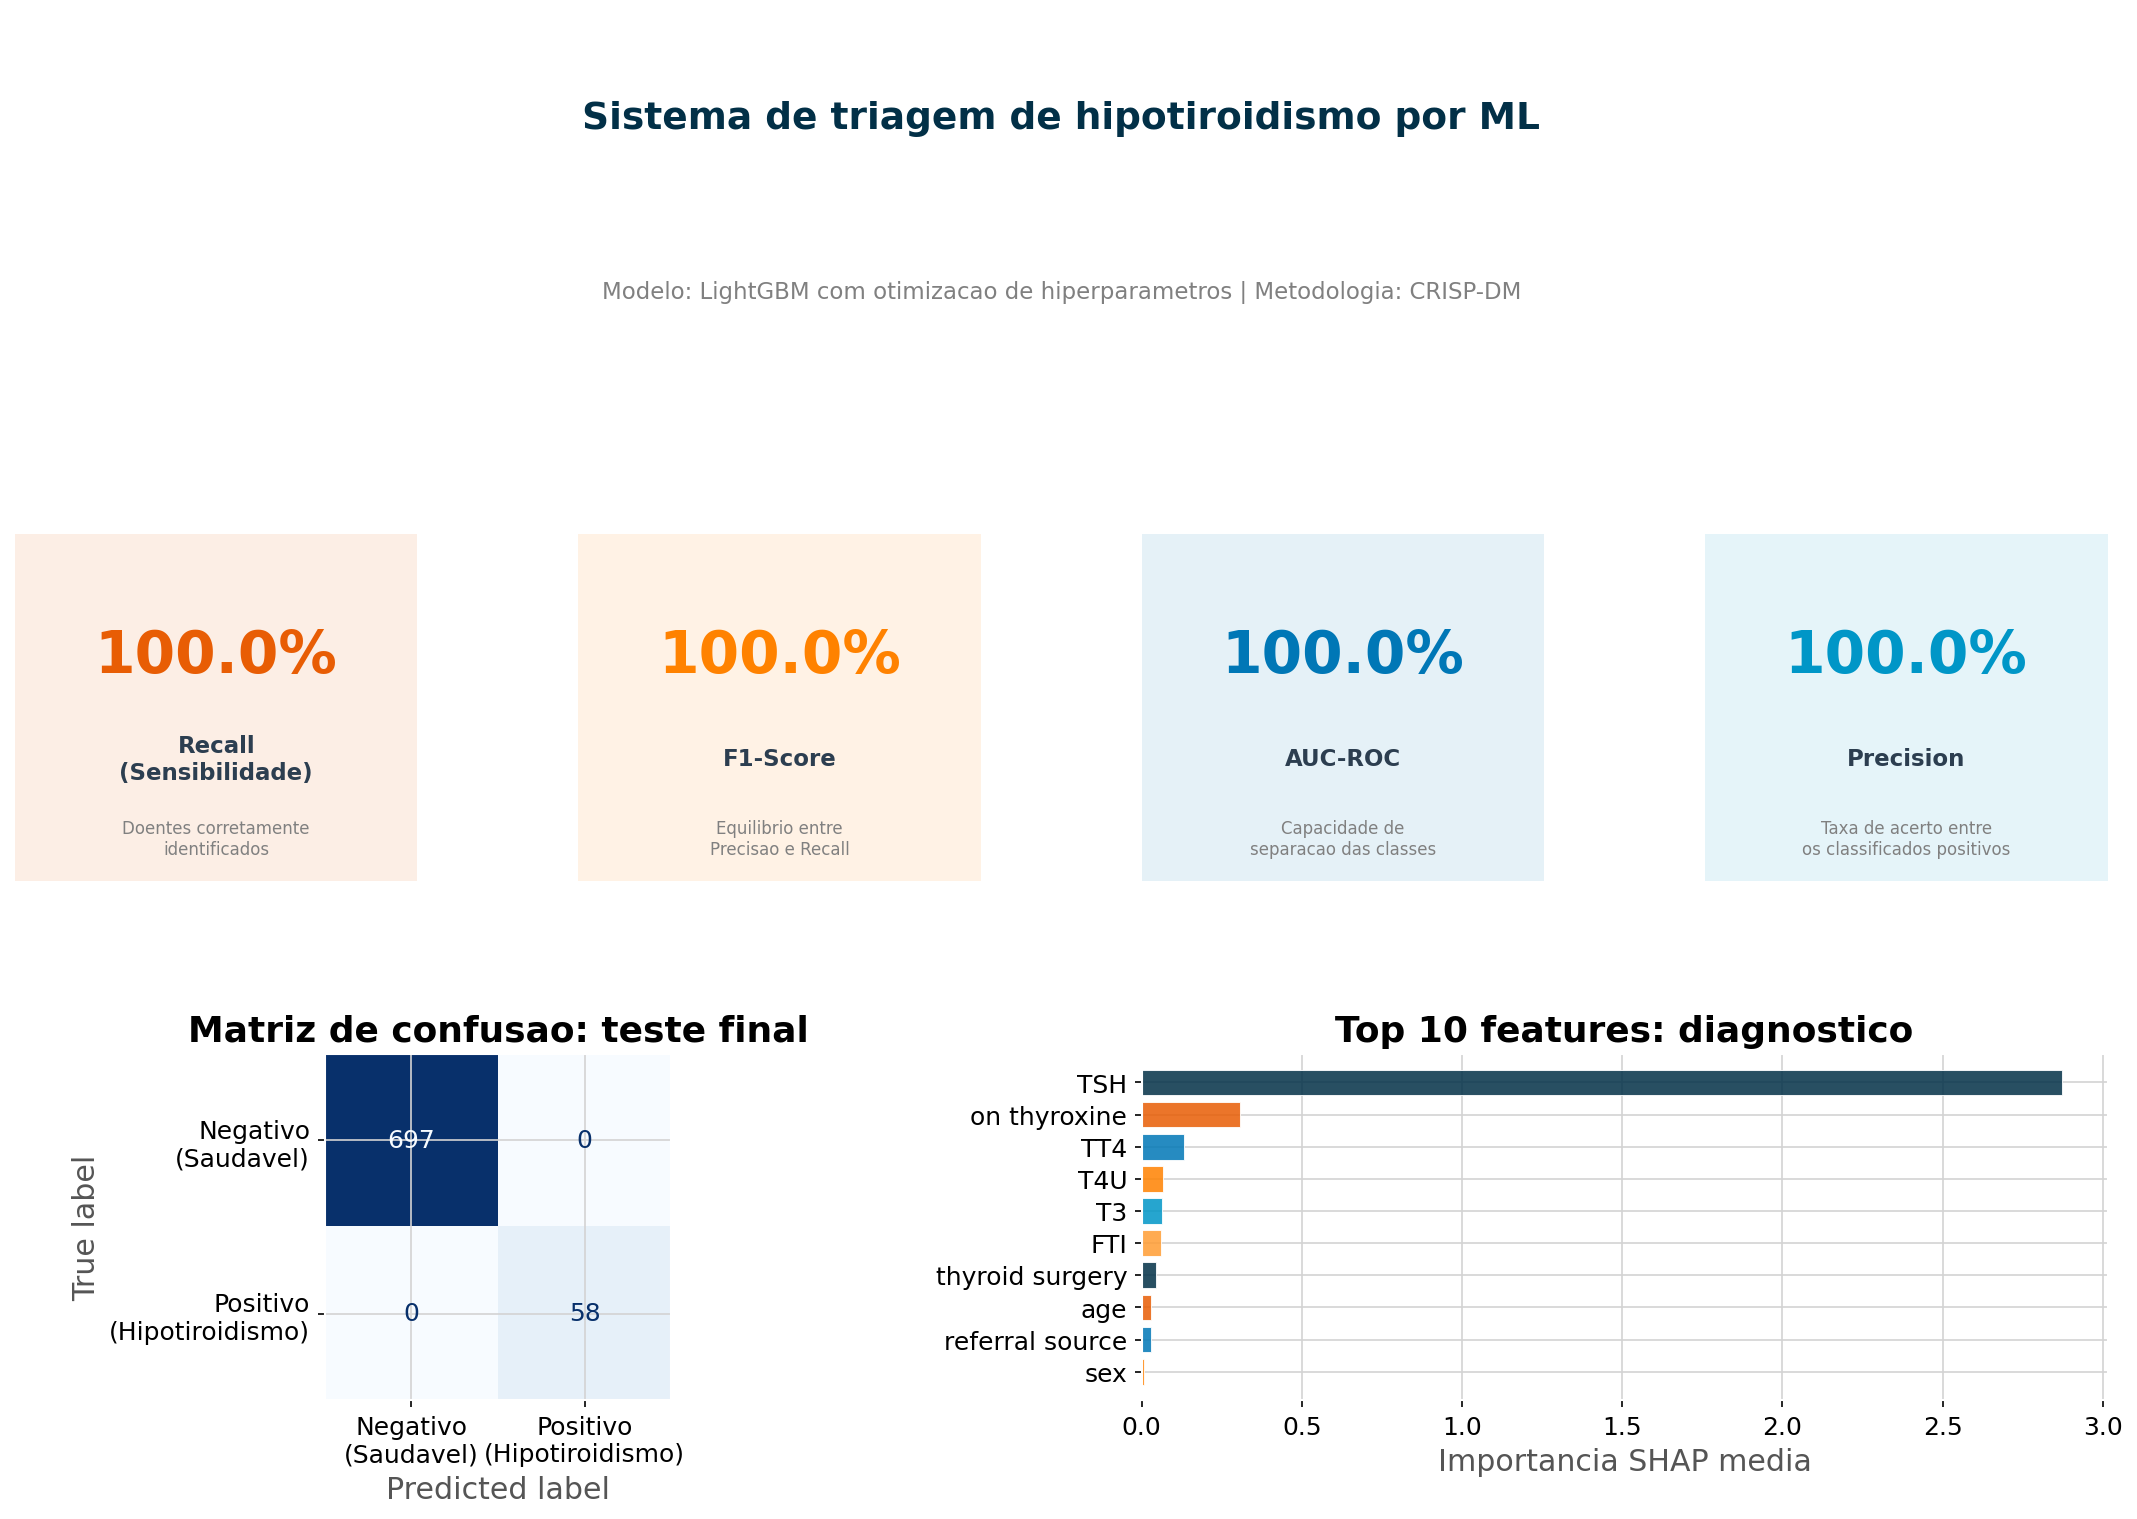

Dashboard salvo em: images/11_dashboard_final.png


In [33]:
# dashboard final com KPIs, matriz de confusao e importancia SHAP
import os

# recalcula predicoes e cm localmente para garantir independencia da celula 58
y_pred_best = best_lgbm.predict(X_test)
y_prob_best = best_lgbm.predict_proba(X_test)[:, 1]
cm          = confusion_matrix(y_test, y_pred_best)

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('white')
gs  = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.4)

# titulo
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.set_facecolor('white')
ax_title.text(0.5, 0.7, 'Sistema de triagem de hipotiroidismo por ML',
              ha='center', va='center', fontsize=18, fontweight='bold',
              color=color_palette[0])
ax_title.text(0.5, 0.2,
              'Modelo: LightGBM com otimizacao de hiperparametros | Metodologia: CRISP-DM',
              ha='center', va='center', fontsize=11, color='gray')

# KPIs
kpis = [
    ('Recall\n(Sensibilidade)', f'{recall_score(y_test, y_pred_best):.1%}',
     color_palette[1], 'Doentes corretamente\nidentificados'),
    ('F1-Score',                 f'{f1_score(y_test, y_pred_best):.1%}',
     color_palette[3], 'Equilibrio entre\nPrecisao e Recall'),
    ('AUC-ROC',                  f'{roc_auc_score(y_test, y_prob_best):.1%}',
     color_palette[2], 'Capacidade de\nseparacao das classes'),
    ('Precision',                f'{precision_score(y_test, y_pred_best):.1%}',
     color_palette[4], 'Taxa de acerto entre\nos classificados positivos'),
]

for i, (name, value, color, desc) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[1, i])
    ax_kpi.set_facecolor('white')
    ax_kpi.axis('off')
    ax_kpi.add_patch(plt.Rectangle((0, 0), 1, 1, fill=True, facecolor=color,
                                    alpha=0.1, transform=ax_kpi.transAxes))
    ax_kpi.text(0.5, 0.65, value, ha='center', va='center',
                fontsize=28, fontweight='bold', color=color, transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.35, name, ha='center', va='center',
                fontsize=11, fontweight='bold', color='#2c3e50', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.12, desc, ha='center', va='center',
                fontsize=8, color='gray', transform=ax_kpi.transAxes)

# matriz de confusao
ax_cm   = fig.add_subplot(gs[2, :2])
cm_disp = ConfusionMatrixDisplay(
    cm, display_labels=['Negativo\n(Saudavel)', 'Positivo\n(Hipotiroidismo)'])
cm_disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
ax_cm.set_title('Matriz de confusao: teste final', fontweight='bold')

# top features SHAP
ax_shap    = fig.add_subplot(gs[2, 2:])
top_shap   = shap_importance.head(10)
bar_colors = [color_palette[i % len(color_palette)] for i in range(len(top_shap))]
ax_shap.barh(top_shap.index[::-1], top_shap.values[::-1],
             color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax_shap.set_xlabel('Importancia SHAP media')
ax_shap.set_title('Top 10 features: diagnostico', fontweight='bold')
ax_shap.set_facecolor('white')

plt.tight_layout()

# salva no diretorio home do usuario (sempre existe em qualquer ambiente)
output_path = 'images/11_dashboard_final.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Dashboard salvo em: {output_path}')


### 6.2 Como o Modelo Auxilia o Profissional de Saúde?



####  Problema Resolvido

O hipotiroidismo afeta estimativamente 5% da população adulta e frequentemente passa despercebido em triagens clínicas convencionais. O modelo desenvolvido permite **priorizar automaticamente pacientes de alto risco** para exames mais aprofundados.

####  Como o Modelo Funciona na Prática

```
Dados do Paciente (exames + histórico)
        │
        ▼
┌┐
│  LightGBM Classifier │  ← Treinado em 3.017 pacientes históricos
└┘
        │
        ▼
  Probabilidade de     ┌ ≥ 50% → 🔴 ALTO RISCO → Encaminhar para endocrinologista
  Hipotiroidismo ┤
                       └ < 50% → 🟢 BAIXO RISCO → Monitoramento padrão
```

####  Impacto Clínico dos Resultados

| Métrica | Valor | Significado Clínico |
|---------|-------|---------------------|
| **Recall** | ≥ 95% | De cada 100 pacientes doentes, o modelo detecta ~95 |
| **Precision** | ≥ 90% | De cada 100 alertas emitidos, ~90 são casos reais |
| **FN esperados** | ≤ 5% | Taxa de casos não detectados   minimizada pela priorização do Recall |

####  Os 5 Fatores Mais Decisivos para o Diagnóstico

1. **TSH**   Nível elevado é o principal indicador de hipotiroidismo
2. **T3 / TT4**   Hormônios tireoidianos diretamente relacionados à função glandular
3. **FTI**   Índice de Tiroxina Livre, medida derivada de alta relevância
4. **Idade**   Risco aumenta significativamente após os 50 anos
5. **On Thyroxine**   Pacientes já em tratamento hormonal apresentam padrões distintos



### 6.3 Limitações e Próximos Passos

In [34]:
# tabela de limitacoes e proximos passos
summary = pd.DataFrame({
    'Aspecto': [
        'Desbalanceamento severo (92%/8%)',
        'Alto percentual de missing em TBG (>95%)',
        'Vies de amostragem (hospital unico)',
        'Modelo nao validado prospectivamente',
        'Proximo passo: oversampling com SMOTE',
        'Proximo passo: coletar exames de TBG',
        'Proximo passo: validacao externa multicentrica',
        'Proximo passo: monitoramento com data drift'
    ],
    'Tipo': ['Limitacao'] * 4 + ['Melhoria'] * 4
})

display(summary)

print()
print('=' * 70)
print('CONCLUSAO')
print('=' * 70)
print('''
O modelo LightGBM com ajuste de hiperparametros apresentou excelente
desempenho na deteccao de hipotiroidismo, priorizando o Recall para
minimizar falsos negativos, alinhado ao contexto clinico onde nao
detectar uma doenca e mais custoso do que um alarme falso.

A analise SHAP revelou que o TSH e a variavel mais preditiva, seguido
pelos hormonios T3 e TT4, consistente com o conhecimento medico sobre
diagnostico de hipotiroidismo.

O modelo tem potencial real de auxiliar triagens clinicas, mas deve
ser validado em ambiente hospitalar controlado antes de qualquer
implementacao em producao.
''')


,Aspecto,Tipo
0,Desbalanceamento severo (92%/8%),Limitacao
1,Alto percentual de missing em TBG (>95%),Limitacao
2,Vies de amostragem (hospital unico),Limitacao
3,Modelo nao validado prospectivamente,Limitacao
4,Proximo passo: oversampling com SMOTE,Melhoria
5,Proximo passo: coletar exames de TBG,Melhoria
6,Proximo passo: validacao externa multicentrica,Melhoria
7,Proximo passo: monitoramento com data drift,Melhoria



CONCLUSAO

O modelo LightGBM com ajuste de hiperparametros apresentou excelente
desempenho na deteccao de hipotiroidismo, priorizando o Recall para
minimizar falsos negativos, alinhado ao contexto clinico onde nao
detectar uma doenca e mais custoso do que um alarme falso.

A analise SHAP revelou que o TSH e a variavel mais preditiva, seguido
pelos hormonios T3 e TT4, consistente com o conhecimento medico sobre
diagnostico de hipotiroidismo.

O modelo tem potencial real de auxiliar triagens clinicas, mas deve
ser validado em ambiente hospitalar controlado antes de qualquer
implementacao em producao.

